In [ ]:

from Model.data_cleaning import clean_flight_data
from Model.feature_engineering import add_feature_engineering
import pandas as pd
import numpy as np

path_2024 = "/Users/crystalguo/Downloads/archive (1)/flight_data_2024.csv"

df_clean, report = clean_flight_data(path_2024)
df = add_feature_engineering(df_clean)

In [18]:
df = df[(df["cancelled"] == 0) & (df["diverted"] == 0)].copy().reset_index(drop=True)

In [ ]:

# OpenFlights airports.dat — free, covers every major airport
airports_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"
airports = pd.read_csv(
    airports_url,
    header=None,
    names=["id", "name", "city", "country", "iata", "icao", 
           "lat", "lon", "altitude", "timezone", "dst", "tz_name", "type", "source"],
)

# Filter to US airports with valid IATA codes
us_airports = airports[
    (airports["country"] == "United States") & 
    (airports["iata"].notna()) & 
    (airports["iata"] != "\\N")
][["iata", "lat", "lon", "altitude", "tz_name"]].copy()

print(f"Loaded {len(us_airports)} US airports")

Loaded 1251 US airports
     iata        lat         lon  altitude            tz_name
3212  BTI  70.134003 -143.582001         2  America/Anchorage
3214  LUR  68.875099 -166.110001        16  America/Anchorage
3215  PIZ  69.732903 -163.005005        22  America/Anchorage
3216  ITO  19.721399 -155.048004        38   Pacific/Honolulu
3217  ORL  28.545500  -81.332901       113   America/New_York


In [27]:
import pandas as pd
from meteostat import Point, Daily
from datetime import datetime
from tqdm import tqdm

# Reset state
weather_dfs = []
skip_reasons = {}

start = datetime(2024, 1, 1)
end = datetime(2024, 12, 31)

for iata, row in tqdm(airport_coords.iterrows(), total=len(airport_coords)):
    try:
        # Drop altitude entirely — let meteostat find the nearest station by lat/lon
        point = Point(float(row["lat"]), float(row["lon"]))
        weather_data = Daily(point, start, end).fetch()
        
        if weather_data is None or len(weather_data) == 0:
            skip_reasons[iata] = "no data"
            continue
        
        weather_data = weather_data.copy()
        weather_data["iata"] = iata
        weather_dfs.append(weather_data)
        
    except Exception as e:
        skip_reasons[iata] = str(e)[:80]

print(f"\n✓ Successfully fetched: {len(weather_dfs)} airports")
print(f"✗ Skipped: {len(skip_reasons)} airports")

if skip_reasons:
    from collections import Counter
    reason_counts = Counter(skip_reasons.values())
    print("\nSkip reasons:")
    for reason, count in reason_counts.most_common(5):
        print(f"  ({count}) {reason}")

100%|██████████| 338/338 [09:46<00:00,  1.73s/it]


✓ Successfully fetched: 333 airports
✗ Skipped: 5 airports

Skip reasons:
  (5) no data


In [ ]:
weather_df = pd.concat(weather_dfs).reset_index()
weather_df = weather_df.rename(columns={"time": "fl_date"})

# usable columns
weather_df = weather_df[["iata", "fl_date", "tavg", "tmin", "tmax",
                          "prcp", "snow", "wspd", "pres"]]

# Convert fl_date to datetime for join later
weather_df["fl_date"] = pd.to_datetime(weather_df["fl_date"])

print(f"Total weather rows: {len(weather_df):,}")
print(f"Unique airports: {weather_df['iata'].nunique()}")
print(f"Date range: {weather_df['fl_date'].min().date()} to {weather_df['fl_date'].max().date()}")
print("\nMissing values per column:")
print(weather_df.isna().sum())

# Check flight coverage
covered = set(weather_df["iata"].unique())
origin_coverage = df["origin"].isin(covered).mean() * 100
dest_coverage = df["dest"].isin(covered).mean() * 100
both_coverage = (df["origin"].isin(covered) & df["dest"].isin(covered)).mean() * 100

print(f"\nFlight coverage:")
print(f"  Origin weather available: {origin_coverage:.2f}% of flights")
print(f"  Dest weather available:   {dest_coverage:.2f}% of flights")
print(f"  Both available:           {both_coverage:.2f}% of flights")



Total weather rows: 121,878
Unique airports: 333
Date range: 2024-01-01 to 2024-12-31

Missing values per column:
iata           0
fl_date        0
tavg         181
tmin         194
tmax         194
prcp        7349
snow       58751
wspd         175
pres         532
dtype: int64

Flight coverage:
  Origin weather available: 99.07% of flights
  Dest weather available:   99.06% of flights
  Both available:           98.16% of flights


# join data

In [30]:
# Ensure fl_date is datetime in both dataframes
df["fl_date"] = pd.to_datetime(df["fl_date"])
weather_df["fl_date"] = pd.to_datetime(weather_df["fl_date"])

print(f"df shape before join: {df.shape}")
print(f"weather_df shape: {weather_df.shape}")

df shape before join: (6965267, 79)
weather_df shape: (121878, 9)


In [31]:
# Rename weather columns with "origin_" prefix and rename iata to origin for the join
origin_weather = weather_df.rename(
    columns={"iata": "origin", **{c: f"origin_{c}" 
             for c in ["tavg", "tmin", "tmax", "prcp", "snow", "wspd", "pres"]}}
)

df_w = df.merge(origin_weather, on=["origin", "fl_date"], how="left")
print(f"After origin join: {df_w.shape}")
print(f"Missing origin_tavg: {df_w['origin_tavg'].isna().sum():,} ({df_w['origin_tavg'].isna().mean()*100:.2f}%)")

After origin join: (6965267, 86)
Missing origin_tavg: 66,572 (0.96%)


In [32]:
# Same for dest
dest_weather = weather_df.rename(
    columns={"iata": "dest", **{c: f"dest_{c}" 
             for c in ["tavg", "tmin", "tmax", "prcp", "snow", "wspd", "pres"]}}
)

df_w = df_w.merge(dest_weather, on=["dest", "fl_date"], how="left")
print(f"After dest join: {df_w.shape}")
print(f"Missing dest_tavg: {df_w['dest_tavg'].isna().sum():,} ({df_w['dest_tavg'].isna().mean()*100:.2f}%)")

After dest join: (6965267, 93)
Missing dest_tavg: 66,845 (0.96%)


In [33]:
# Drop flights missing origin OR dest weather
before = len(df_w)
df_w = df_w.dropna(subset=["origin_tavg", "dest_tavg"])
after = len(df_w)
print(f"Dropped {before - after:,} flights without weather ({(before-after)/before*100:.2f}%)")
print(f"Final rows: {after:,}")

Dropped 131,254 flights without weather (1.88%)
Final rows: 6,834,013


In [34]:
# Snow and prcp: fill with 0 (missing usually means none measured)
for col in ["origin_snow", "dest_snow", "origin_prcp", "dest_prcp"]:
    df_w[col] = df_w[col].fillna(0)

# Wind speed and pressure: fill with airport monthly mean, then global median
for col in ["origin_wspd", "dest_wspd", "origin_pres", "dest_pres"]:
    # Compute monthly mean per airport
    airport_col = "origin" if col.startswith("origin") else "dest"
    df_w[col] = df_w.groupby([airport_col, "month"])[col].transform(
        lambda x: x.fillna(x.mean())
    )
    # Anything still missing: global median
    df_w[col] = df_w[col].fillna(df_w[col].median())

# Temperature: airport-month mean, then median
for col in ["origin_tmin", "origin_tmax", "dest_tmin", "dest_tmax"]:
    airport_col = "origin" if col.startswith("origin") else "dest"
    df_w[col] = df_w.groupby([airport_col, "month"])[col].transform(
        lambda x: x.fillna(x.mean())
    )
    df_w[col] = df_w[col].fillna(df_w[col].median())

# Verify no NaN
weather_cols = [c for c in df_w.columns if c.startswith(("origin_", "dest_")) 
                and any(w in c for w in ["tavg", "tmin", "tmax", "prcp", "snow", "wspd", "pres"])]
print("Remaining NaNs in weather columns:")
print(df_w[weather_cols].isna().sum())

Remaining NaNs in weather columns:
origin_tavg    0
origin_tmin    0
origin_tmax    0
origin_prcp    0
origin_snow    0
origin_wspd    0
origin_pres    0
dest_tavg      0
dest_tmin      0
dest_tmax      0
dest_prcp      0
dest_snow      0
dest_wspd      0
dest_pres      0
dtype: int64


In [35]:
# Binary bad weather flags
df_w["origin_bad_weather"] = (
    (df_w["origin_prcp"] > 10) |       # heavy rain (>10mm)
    (df_w["origin_snow"] > 0) |        # any snow
    (df_w["origin_wspd"] > 30)         # strong wind (>30 km/h)
).astype(int)

df_w["dest_bad_weather"] = (
    (df_w["dest_prcp"] > 10) |
    (df_w["dest_snow"] > 0) |
    (df_w["dest_wspd"] > 30)
).astype(int)

# Wind category (simpler numeric than one-hot for tree models)
def wind_cat(wspd):
    # 0=calm, 1=breezy, 2=windy, 3=high_wind
    return pd.cut(wspd, bins=[-1, 10, 20, 30, 500], labels=[0, 1, 2, 3]).astype(float)

df_w["origin_wind_cat"] = wind_cat(df_w["origin_wspd"])
df_w["dest_wind_cat"] = wind_cat(df_w["dest_wspd"])

# Quick sanity check — bad weather should correlate with delays
print("Delay rate by origin weather:")
print(df_w.groupby("origin_bad_weather")["is_dep_delayed"].agg(["mean", "count"]))

print("\nDelay rate by origin wind category:")
print(df_w.groupby("origin_wind_cat")["is_dep_delayed"].agg(["mean", "count"]))

Delay rate by origin weather:
                        mean    count
origin_bad_weather                   
0                   0.188389  6140088
1                    0.29139   693925

Delay rate by origin wind category:
                     mean    count
origin_wind_cat                   
0.0              0.186425  2322993
1.0              0.201718  3678098
2.0              0.216932   765812
3.0              0.265191    67110


# Define the two targets

In [40]:
# Classification target: delayed more than 15 minutes (FAA standard)

df["is_dep_delayed"] = (df["dep_delay"] > 15).astype(int)



# check
print("Classification target distribution:")
print(df["is_dep_delayed"].value_counts(normalize=True).round(4))
print(f"\nTotal flights: {len(df):,}")
print(f"Delayed flights (>15 min): {df['is_dep_delayed'].sum():,}")

Classification target distribution:
is_dep_delayed
0    0.8006
1    0.1994
Name: proportion, dtype: float64

Total flights: 6,965,267
Delayed flights (>15 min): 1,388,886


In [41]:


train_mask = (df_w["fl_date"] >= "2024-01-01") & (df_w["fl_date"] <= "2024-08-31")
val_mask   = (df_w["fl_date"] >= "2024-09-01") & (df_w["fl_date"] <= "2024-10-31")
test_mask  = (df_w["fl_date"] >= "2024-11-01") & (df_w["fl_date"] <= "2024-12-31")

train_df = df_w.loc[train_mask].copy()
val_df   = df_w.loc[val_mask].copy()
test_df  = df_w.loc[test_mask].copy()

# Report sizes
total = len(df_w)
print(f"Total rows: {total:,}\n")

for name, d in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name}:")
    print(f"  Rows:       {len(d):,} ({len(d)/total*100:.1f}%)")
    print(f"  Date range: {d['fl_date'].min().date()} to {d['fl_date'].max().date()}")
    print(f"  Delay rate: {d['is_dep_delayed'].mean()*100:.2f}%")
    print()

# Leakage checks
assert train_df["fl_date"].max() < val_df["fl_date"].min(), "Train/val overlap!"
assert val_df["fl_date"].max() < test_df["fl_date"].min(), "Val/test overlap!"
print("✓ No date overlap between splits")

# Unseen category check
train_origins = set(train_df["origin"].unique())
test_origins = set(test_df["origin"].unique())
unseen = test_origins - train_origins
print(f"\nOrigins in test but not train: {len(unseen)}")
if unseen:
    print(f"  Examples: {list(unseen)[:5]}")

train_carriers = set(train_df["op_unique_carrier"].unique())
test_carriers = set(test_df["op_unique_carrier"].unique())
unseen_c = test_carriers - train_carriers
print(f"Carriers in test but not train: {len(unseen_c)}")


Total rows: 6,834,013

Train:
  Rows:       4,530,789 (66.3%)
  Date range: 2024-01-01 to 2024-08-31
  Delay rate: 22.11%

Validation:
  Rows:       1,169,039 (17.1%)
  Date range: 2024-09-01 to 2024-10-31
  Delay rate: 13.72%

Test:
  Rows:       1,134,185 (16.6%)
  Date range: 2024-11-01 to 2024-12-31
  Delay rate: 17.35%

✓ No date overlap between splits

Origins in test but not train: 3
  Examples: ['EAU', 'PQI', 'MGW']
Carriers in test but not train: 0


In [43]:
# Final predictor selection — now includes weather
target_cols = ["dep_delay", "is_dep_delayed"]
reference_cols = ["fl_date"]  # keep for now, will drop before fitting

predictor_cols = [
    # Calendar / time
    "month",
    "day_of_week",
    "is_weekend",
    "season",
    "scheduled_dep_hour",
    "is_peak_hour",
    
    # Schedule / route
    "crs_elapsed_time",
    "distance",
    "route_distance_bucket",
    
    # Categorical
    "op_unique_carrier",
    "origin",
    "dest",
    "route_id",
    
    # NEW: Weather features — origin
    "origin_tavg",
    "origin_tmin",
    "origin_tmax",
    "origin_prcp",
    "origin_snow",
    "origin_wspd",
    "origin_pres",
    "origin_bad_weather",
    "origin_wind_cat",
    
    # NEW: Weather features — destination
    "dest_tavg",
    "dest_prcp",
    "dest_wspd",
    "dest_bad_weather",
    "dest_wind_cat",
]

keep_cols = target_cols + reference_cols + predictor_cols

def select_cols(d, cols):
    existing = [c for c in cols if c in d.columns]
    return d[existing].copy()

train_df = select_cols(train_df, keep_cols)
val_df   = select_cols(val_df, keep_cols)
test_df  = select_cols(test_df, keep_cols)

print(f"Columns kept: {len(train_df.columns)}")
print(list(train_df.columns))
print(f"\nTrain memory: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Columns kept: 30
['dep_delay', 'is_dep_delayed', 'fl_date', 'month', 'day_of_week', 'is_weekend', 'season', 'scheduled_dep_hour', 'is_peak_hour', 'crs_elapsed_time', 'distance', 'route_distance_bucket', 'op_unique_carrier', 'origin', 'dest', 'route_id', 'origin_tavg', 'origin_tmin', 'origin_tmax', 'origin_prcp', 'origin_snow', 'origin_wspd', 'origin_pres', 'origin_bad_weather', 'origin_wind_cat', 'dest_tavg', 'dest_prcp', 'dest_wspd', 'dest_bad_weather', 'dest_wind_cat']

Train memory: 1.31 GB


In [ ]:
categorical_cols = [
    "season",
    "route_distance_bucket",
    "op_unique_carrier",
    "origin",
    "dest",
    "route_id",
    "origin_wind_cat",
    "dest_wind_cat",
]

for df_ in [train_df, val_df, test_df]:
    for col in categorical_cols:
        if col in df_.columns:
            df_[col] = df_[col].astype("category")

print("Categorical dtypes set.")
print(train_df.dtypes)

# Ensure val and test use the same categories as train
for col in categorical_cols:
    if col in train_df.columns:
        train_cats = train_df[col].cat.categories
        val_df[col] = val_df[col].cat.set_categories(train_cats)
        test_df[col] = test_df[col].cat.set_categories(train_cats)

# Check how many NaN this creates
for col in categorical_cols:
    if col in test_df.columns:
        n_nan = test_df[col].isna().sum()
        if n_nan > 0:
            print(f"Test {col}: {n_nan} unseen values (now NaN)")

Categorical dtypes set.
dep_delay                       float64
is_dep_delayed                    Int64
fl_date                  datetime64[us]
month                             int64
day_of_week                       int64
is_weekend                        Int64
season                         category
scheduled_dep_hour              float64
is_peak_hour                      Int64
crs_elapsed_time                float64
distance                        float64
route_distance_bucket          category
op_unique_carrier              category
origin                         category
dest                           category
route_id                       category
origin_tavg                     Float64
origin_tmin                     Float64
origin_tmax                     Float64
origin_prcp                     Float64
origin_snow                     Float64
origin_wspd                     Float64
origin_pres                     Float64
origin_bad_weather                int64
origin_wind_cat 

In [53]:


# ----- 1. Compute baselines from TRAINING data only -----
GLOBAL_MEAN_DEP_DELAY = train_df["dep_delay"].mean()

print(f"Global mean dep_delay (train): {GLOBAL_MEAN_DEP_DELAY:.2f} minutes")

# Origin baseline — with row count for minimum-support filtering
origin_stats = (
    train_df.groupby("origin", observed=True)["dep_delay"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "origin_avg_dep_delay", "count": "origin_n"})
)

# Carrier baseline
carrier_stats = (
    train_df.groupby("op_unique_carrier", observed=True)["dep_delay"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "carrier_avg_dep_delay", "count": "carrier_n"})
)

# Route baseline
route_stats = (
    train_df.groupby("route_id", observed=True)["dep_delay"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "route_avg_dep_delay", "count": "route_n"})
)

print(f"\nBaselines computed:")
print(f"  Origins:  {len(origin_stats):,}")
print(f"  Carriers: {len(carrier_stats):,}")
print(f"  Routes:   {len(route_stats):,}")

Global mean dep_delay (train): 14.89 minutes

Baselines computed:
  Origins:  330
  Carriers: 15
  Routes:   6,377


In [54]:
# ----- 2. Smooth low-volume categories toward the global mean -----
# A route with 2 flights in training shouldn't dominate; shrink it toward the global mean.
# This is Bayesian-style smoothing: more samples = trust the group mean, fewer = trust global.

def smooth_baseline(stats_df, value_col, count_col, global_mean, min_n=50):
    """
    Replace group means with a smoothed version:
      smoothed = (n * group_mean + min_n * global_mean) / (n + min_n)
    When n >> min_n, this ≈ group_mean. When n << min_n, this ≈ global_mean.
    """
    n = stats_df[count_col]
    smoothed = (n * stats_df[value_col] + min_n * global_mean) / (n + min_n)
    return smoothed

origin_stats["origin_avg_dep_delay"] = smooth_baseline(
    origin_stats, "origin_avg_dep_delay", "origin_n", GLOBAL_MEAN_DEP_DELAY, min_n=50
)
carrier_stats["carrier_avg_dep_delay"] = smooth_baseline(
    carrier_stats, "carrier_avg_dep_delay", "carrier_n", GLOBAL_MEAN_DEP_DELAY, min_n=200
)
route_stats["route_avg_dep_delay"] = smooth_baseline(
    route_stats, "route_avg_dep_delay", "route_n", GLOBAL_MEAN_DEP_DELAY, min_n=30
)

In [55]:
# ----- 3. Apply baselines to train, val, and test -----
origin_map = origin_stats["origin_avg_dep_delay"].to_dict()
carrier_map = carrier_stats["carrier_avg_dep_delay"].to_dict()
route_map = route_stats["route_avg_dep_delay"].to_dict()

def add_baselines(df):
    df = df.copy()
    
    # Convert to string for the map, then to float so fillna works
    df["origin_avg_dep_delay"] = (
        df["origin"].astype(str).map(origin_map)
        .astype(float)
        .fillna(GLOBAL_MEAN_DEP_DELAY)
    )
    df["carrier_avg_dep_delay"] = (
        df["op_unique_carrier"].astype(str).map(carrier_map)
        .astype(float)
        .fillna(GLOBAL_MEAN_DEP_DELAY)
    )
    df["route_avg_dep_delay"] = (
        df["route_id"].astype(str).map(route_map)
        .astype(float)
        .fillna(GLOBAL_MEAN_DEP_DELAY)
    )
    return df

train_df = add_baselines(train_df)
val_df   = add_baselines(val_df)
test_df  = add_baselines(test_df)
# ----- 4. Save the baseline dicts for the Shiny app later -----
import pickle
from pathlib import Path

Path("models").mkdir(exist_ok=True)
baseline_lookups = {
    "origin_avg_dep_delay": origin_map,
    "carrier_avg_dep_delay": carrier_map,
    "route_avg_dep_delay": route_map,
    "global_mean_dep_delay": GLOBAL_MEAN_DEP_DELAY,
}
with open("models/baseline_lookups.pkl", "wb") as f:
    pickle.dump(baseline_lookups, f)
print("✓ Saved baseline_lookups.pkl for Shiny app")

✓ Saved baseline_lookups.pkl for Shiny app


In [56]:
# ----- 5. Verification -----
print("Training set baseline statistics:")
print(train_df[["origin_avg_dep_delay", "carrier_avg_dep_delay", "route_avg_dep_delay"]].describe())

print("\nUnseen-value fallback check (how often the global mean was used):")
for col, name in [
    ("origin", "origin_avg_dep_delay"),
    ("op_unique_carrier", "carrier_avg_dep_delay"),
    ("route_id", "route_avg_dep_delay"),
]:
    n_fallback = (
        (val_df[name] == GLOBAL_MEAN_DEP_DELAY).sum()
        + (test_df[name] == GLOBAL_MEAN_DEP_DELAY).sum()
    )
    print(f"  {name}: {n_fallback:,} rows in val+test used global-mean fallback")

Training set baseline statistics:
       origin_avg_dep_delay  carrier_avg_dep_delay  route_avg_dep_delay
count          4.530789e+06           4.530789e+06         4.530789e+06
mean           1.489665e+01           1.489312e+01         1.490853e+01
std            4.014190e+00           5.005063e+00         6.375452e+00
min           -3.433903e+00           5.271697e+00        -4.723681e+00
25%            1.228295e+01           1.228162e+01         1.040407e+01
50%            1.435008e+01           1.350748e+01         1.444549e+01
75%            1.714914e+01           1.535476e+01         1.892108e+01
max            4.055988e+01           2.480845e+01         8.274505e+01

Unseen-value fallback check (how often the global mean was used):
  origin_avg_dep_delay: 182 rows in val+test used global-mean fallback
  carrier_avg_dep_delay: 0 rows in val+test used global-mean fallback
  route_avg_dep_delay: 3,803 rows in val+test used global-mean fallback


In [57]:
print("Final check — baseline columns in all splits:")
for df_name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols = ["origin_avg_dep_delay", "carrier_avg_dep_delay", "route_avg_dep_delay"]
    nulls = df_[cols].isna().sum().sum()
    print(f"  {df_name}: {len(df_):,} rows, nulls in baseline cols = {nulls}")
    
print("\nFinal column list:")
print(list(train_df.columns))

Final check — baseline columns in all splits:
  train: 4,530,789 rows, nulls in baseline cols = 0
  val: 1,169,039 rows, nulls in baseline cols = 0
  test: 1,134,185 rows, nulls in baseline cols = 0

Final column list:
['dep_delay', 'is_dep_delayed', 'fl_date', 'month', 'day_of_week', 'is_weekend', 'season', 'scheduled_dep_hour', 'is_peak_hour', 'crs_elapsed_time', 'distance', 'route_distance_bucket', 'op_unique_carrier', 'origin', 'dest', 'route_id', 'origin_tavg', 'origin_tmin', 'origin_tmax', 'origin_prcp', 'origin_snow', 'origin_wspd', 'origin_pres', 'origin_bad_weather', 'origin_wind_cat', 'dest_tavg', 'dest_prcp', 'dest_wspd', 'dest_bad_weather', 'dest_wind_cat', 'origin_avg_dep_delay', 'carrier_avg_dep_delay', 'route_avg_dep_delay']


## Setup and Helpers

In [58]:
import numpy as np
import pandas as pd
import pickle
import json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# Config
RANDOM_SEED = 42
SAMPLE_SIZE = 2_000_000
N_FOLDS = 3

# Paths
Path("models").mkdir(exist_ok=True)
Path("reports/figures/modeling").mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")

✓ Setup complete


In [61]:
# Feature columns — what goes into X
PREDICTOR_COLS = [
    # Calendar / time
    "month",
    "day_of_week",
    "is_weekend",
    "season",
    "scheduled_dep_hour",
    "is_peak_hour",
    # Schedule / route
    "crs_elapsed_time",
    "distance",
    "route_distance_bucket",
    # Categorical
    "op_unique_carrier",
    "origin",
    "dest",
    "route_id",
    # Leakage-safe baselines
    "origin_avg_dep_delay",
    "carrier_avg_dep_delay",
    "route_avg_dep_delay",
    # NEW: Weather — origin (9 features)
    "origin_tavg",
    "origin_tmin",
    "origin_tmax",
    "origin_prcp",
    "origin_snow",
    "origin_wspd",
    "origin_pres",
    "origin_bad_weather",
    "origin_wind_cat",
    # NEW: Weather — destination (5 features)
    "dest_tavg",
    "dest_prcp",
    "dest_wspd",
    "dest_bad_weather",
    "dest_wind_cat",
]

CATEGORICAL_COLS = [
    "season",
    "route_distance_bucket",
    "op_unique_carrier",
    "origin",
    "dest",
    "route_id",
    # NEW: wind categories are ordinal categoricals
    "origin_wind_cat",
    "dest_wind_cat",
]

TARGET_CLF = "is_dep_delayed"
TARGET_REG = "dep_delay"

print(f"Predictors: {len(PREDICTOR_COLS)}")
print(f"Categorical: {len(CATEGORICAL_COLS)}")

Predictors: 30
Categorical: 8


In [62]:
def stratified_sample(df, target_col, group_col, n_rows, seed=RANDOM_SEED):
    """
    Stratified sample preserving joint distribution of target_col and group_col.
    Uses sample weights so columns stay as columns, not index.
    """
    frac = n_rows / len(df)
    if frac >= 1.0:
        return df.copy()
    
    # Use sample directly on groupby — keeps all columns intact
    sampled = (
        df.groupby([target_col, group_col], observed=True, group_keys=False)
        [df.columns.tolist()]  # explicitly select all columns
        .sample(frac=frac, random_state=seed)
    )
    return sampled.reset_index(drop=True)


# Rerun
train_sample = stratified_sample(
    train_df, target_col="is_dep_delayed", group_col="month", n_rows=SAMPLE_SIZE
)

print(f"Sample size: {len(train_sample):,}")
print(f"Columns: {list(train_sample.columns)[:10]}...")  # first 10 cols
print(f"Sample delay rate: {train_sample['is_dep_delayed'].mean()*100:.2f}% "
      f"(full train: {train_df['is_dep_delayed'].mean()*100:.2f}%)")
print(f"\nDate range: {train_sample['fl_date'].min().date()} to {train_sample['fl_date'].max().date()}")

Sample size: 2,000,000
Columns: ['dep_delay', 'is_dep_delayed', 'fl_date', 'month', 'day_of_week', 'is_weekend', 'season', 'scheduled_dep_hour', 'is_peak_hour', 'crs_elapsed_time']...
Sample delay rate: 22.11% (full train: 22.11%)

Date range: 2024-01-01 to 2024-08-31


In [63]:
def make_cv_folds(df, date_col="fl_date"):
    """Expanding-window CV folds within 2024 training period."""
    folds = [
        # (train_start, train_end, val_start, val_end)
        ("2024-01-01", "2024-04-30", "2024-05-01", "2024-05-31"),
        ("2024-01-01", "2024-05-31", "2024-06-01", "2024-07-31"),
        ("2024-01-01", "2024-07-31", "2024-08-01", "2024-08-31"),
    ]
    
    fold_indices = []
    for i, (tr_start, tr_end, va_start, va_end) in enumerate(folds, 1):
        train_mask = (df[date_col] >= tr_start) & (df[date_col] <= tr_end)
        val_mask = (df[date_col] >= va_start) & (df[date_col] <= va_end)
        
        tr_idx = df.index[train_mask].to_numpy()
        va_idx = df.index[val_mask].to_numpy()
        
        print(f"Fold {i}: train {tr_start} → {tr_end} ({len(tr_idx):,} rows) | "
              f"val {va_start} → {va_end} ({len(va_idx):,} rows)")
        fold_indices.append((tr_idx, va_idx))
    
    return fold_indices

cv_folds = make_cv_folds(train_sample)

Fold 1: train 2024-01-01 → 2024-04-30 (953,569 rows) | val 2024-05-01 → 2024-05-31 (259,358 rows)
Fold 2: train 2024-01-01 → 2024-05-31 (1,212,927 rows) | val 2024-06-01 → 2024-07-31 (525,701 rows)
Fold 3: train 2024-01-01 → 2024-07-31 (1,738,628 rows) | val 2024-08-01 → 2024-08-31 (261,372 rows)


In [112]:
def compute_baselines_for_fold(fold_train_df, min_n_origin=50, min_n_carrier=200, min_n_route=30):
    """
    Compute leakage-safe baselines from fold training data.
    Returns a dict of lookup maps + the global mean.
    """
    global_mean = fold_train_df["dep_delay"].mean()
    
    def smooth(stats, value_col, count_col, min_n):
        n = stats[count_col]
        return (n * stats[value_col] + min_n * global_mean) / (n + min_n)
    
    origin_stats = (fold_train_df.groupby("origin", observed=True)["dep_delay"]
                    .agg(["mean", "count"]))
    origin_stats["smoothed"] = smooth(origin_stats, "mean", "count", min_n_origin)
    
    carrier_stats = (fold_train_df.groupby("op_unique_carrier", observed=True)["dep_delay"]
                     .agg(["mean", "count"]))
    carrier_stats["smoothed"] = smooth(carrier_stats, "mean", "count", min_n_carrier)
    
    route_stats = (fold_train_df.groupby("route_id", observed=True)["dep_delay"]
                   .agg(["mean", "count"]))
    route_stats["smoothed"] = smooth(route_stats, "mean", "count", min_n_route)
    
    return {
        "origin_map": origin_stats["smoothed"].to_dict(),
        "carrier_map": carrier_stats["smoothed"].to_dict(),
        "route_map": route_stats["smoothed"].to_dict(),
        "global_mean": global_mean,
    }


def apply_baselines(df, baselines):
    """Apply baselines to a dataframe, filling unseen values with the global mean."""
    df = df.copy()
    gm = baselines["global_mean"]
    df["origin_avg_dep_delay"] = (
        df["origin"].astype(str).map(baselines["origin_map"]).astype(float).fillna(gm)
    )
    df["carrier_avg_dep_delay"] = (
        df["op_unique_carrier"].astype(str).map(baselines["carrier_map"]).astype(float).fillna(gm)
    )
    df["route_avg_dep_delay"] = (
        df["route_id"].astype(str).map(baselines["route_map"]).astype(float).fillna(gm)
    )
    return df

In [65]:
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    """Compute all classification metrics at once."""
    y_pred = (y_prob >= threshold).astype(int)
    
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "threshold": threshold,
    }


def find_best_f1_threshold(y_true, y_prob, n_thresholds=50):
    """Scan thresholds to find the one that maximizes F1."""
    thresholds = np.linspace(0.1, 0.9, n_thresholds)
    f1_scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    best_idx = int(np.argmax(f1_scores))
    return thresholds[best_idx], f1_scores[best_idx]

In [66]:
def run_cv(model_name, train_fn, predict_fn, train_sample, cv_folds, predictor_cols, target_col):
    """
    Run 3-fold CV for a model.
    
    train_fn(X_train, y_train, X_val, y_val) -> fitted_model
    predict_fn(model, X) -> predicted probabilities
    """
    fold_metrics = []
    
    for fold_num, (tr_idx, va_idx) in enumerate(cv_folds, 1):
        print(f"\n  Fold {fold_num}...", end=" ")
        
        fold_train = train_sample.loc[tr_idx]
        fold_val = train_sample.loc[va_idx]
        
        # Recompute baselines using only fold training data
        baselines = compute_baselines_for_fold(fold_train)
        fold_train = apply_baselines(fold_train, baselines)
        fold_val = apply_baselines(fold_val, baselines)
        
        # Build X/y
        X_tr = fold_train[predictor_cols]
        y_tr = fold_train[target_col].values
        X_va = fold_val[predictor_cols]
        y_va = fold_val[target_col].values
        
        # Train + predict
        model = train_fn(X_tr, y_tr, X_va, y_va)
        y_prob = predict_fn(model, X_va)
        
        # Metrics
        m = evaluate_predictions(y_va, y_prob)
        m["fold"] = fold_num
        m["n_train"] = len(X_tr)
        m["n_val"] = len(X_va)
        fold_metrics.append(m)
        
        print(f"ROC-AUC: {m['roc_auc']:.4f} | PR-AUC: {m['pr_auc']:.4f} | Brier: {m['brier']:.4f}")
    
    df_metrics = pd.DataFrame(fold_metrics)
    df_metrics["model"] = model_name
    
    print(f"\n  Mean: ROC-AUC {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std():.4f} | "
          f"PR-AUC {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std():.4f}")
    
    return df_metrics

In [67]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

def build_preprocessor(X_train, min_category_count=100):
    """
    Creates a ColumnTransformer that:
      - One-hot encodes categoricals, grouping rare values under 'other'
      - Standardizes numeric features
    
    Returns the fitted preprocessor.
    """
    # Identify rare categories per column and replace with 'other'
    numeric_cols = [c for c in X_train.columns if c not in CATEGORICAL_COLS]
    
    preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_category_count,
            sparse_output=True,
        ), CATEGORICAL_COLS),
        ("num", StandardScaler(), numeric_cols),
    ])
    
    return preprocessor

In [68]:
# We'll accumulate CV results here and compare at the end
all_cv_results = []
best_params_by_model = {}

Step 2 — Logistic Regression

In [ ]:


#!pip install optuna

import sys
#!{sys.executable} -m pip install optuna lightgbm xgboost catboost shap
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Quiet down Optuna's verbose logging
optuna.logging.set_verbosity(optuna.logging.WARNING)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [70]:
def make_logreg_train_fn(C, penalty, solver):
    """
    Returns a train function with fixed hyperparameters.
    Used inside CV so each fold fits its own pipeline.
    """
    def train_fn(X_train, y_train, X_val, y_val):
        preprocessor = build_preprocessor(X_train, min_category_count=100)
        
        model = Pipeline([
            ("preprocess", preprocessor),
            ("clf", LogisticRegression(
                C=C,
                penalty=penalty,
                solver=solver,
                max_iter=1000,
                random_state=RANDOM_SEED,
                n_jobs=-1,
            )),
        ])
        model.fit(X_train, y_train)
        return model
    return train_fn


def logreg_predict_fn(model, X):
    return model.predict_proba(X)[:, 1]

In [71]:
def logreg_objective(trial):
    # Hyperparameter search space
    C = trial.suggest_float("C", 0.01, 10.0, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    solver = "liblinear"  # supports both l1 and l2
    
    train_fn = make_logreg_train_fn(C, penalty, solver)
    
    # Run CV — silent mode
    fold_prauc = []
    for fold_num, (tr_idx, va_idx) in enumerate(cv_folds, 1):
        fold_train = train_sample.loc[tr_idx]
        fold_val = train_sample.loc[va_idx]
        
        baselines = compute_baselines_for_fold(fold_train)
        fold_train = apply_baselines(fold_train, baselines)
        fold_val = apply_baselines(fold_val, baselines)
        
        X_tr = fold_train[PREDICTOR_COLS]
        y_tr = fold_train[TARGET_CLF].values
        X_va = fold_val[PREDICTOR_COLS]
        y_va = fold_val[TARGET_CLF].values
        
        model = train_fn(X_tr, y_tr, X_va, y_va)
        y_prob = logreg_predict_fn(model, X_va)
        fold_prauc.append(average_precision_score(y_va, y_prob))
    
    return np.mean(fold_prauc)

In [75]:
# Check NaN in each feature of the training sample
print("NaN counts in train_sample predictors:")
nan_counts = train_sample[PREDICTOR_COLS].isna().sum()
print(nan_counts[nan_counts > 0])

print("\nTotal predictor columns:", len(PREDICTOR_COLS))
print("Columns with any NaN:", (nan_counts > 0).sum())

NaN counts in train_sample predictors:
scheduled_dep_hour    1
is_peak_hour          1
dtype: int64

Total predictor columns: 30
Columns with any NaN: 2


In [76]:
# Drop rows with NaN in any predictor
before = len(train_sample)
train_sample = train_sample.dropna(subset=PREDICTOR_COLS).copy()
after = len(train_sample)
print(f"Dropped {before - after} rows with NaN")
print(f"train_sample: {after:,} rows")

# Also check val_df and test_df — do the same if needed
for name, d in [("val_df", val_df), ("test_df", test_df)]:
    nan_count = d[PREDICTOR_COLS].isna().any(axis=1).sum()
    if nan_count > 0:
        print(f"{name}: {nan_count} rows with NaN — dropping")
        if name == "val_df":
            val_df = d.dropna(subset=PREDICTOR_COLS).copy()
        else:
            test_df = d.dropna(subset=PREDICTOR_COLS).copy()

Dropped 1 rows with NaN
train_sample: 1,999,999 rows
val_df: 1169039 rows with NaN — dropping
test_df: 563669 rows with NaN — dropping


In [77]:
# Rebuild CV folds on cleaned sample
cv_folds = make_cv_folds(train_sample)

Fold 1: train 2024-01-01 → 2024-04-30 (953,568 rows) | val 2024-05-01 → 2024-05-31 (259,358 rows)
Fold 2: train 2024-01-01 → 2024-05-31 (1,212,926 rows) | val 2024-06-01 → 2024-07-31 (525,701 rows)
Fold 3: train 2024-01-01 → 2024-07-31 (1,738,627 rows) | val 2024-08-01 → 2024-08-31 (261,372 rows)


In [78]:
print("Running Optuna for Logistic Regression (20 trials)...")
logreg_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="logreg",
)
logreg_study.optimize(logreg_objective, n_trials=20, show_progress_bar=True)

print(f"\nBest PR-AUC: {logreg_study.best_value:.4f}")
print(f"Best params: {logreg_study.best_params}")

best_params_by_model["LogisticRegression"] = logreg_study.best_params

Running Optuna for Logistic Regression (20 trials)...


Best trial: 13. Best value: 0.408001: 100%|██████████| 20/20 [1:02:28<00:00, 187.41s/it]


Best PR-AUC: 0.4080
Best params: {'C': 0.010578034120028803, 'penalty': 'l2'}


In [79]:
best = logreg_study.best_params
train_fn = make_logreg_train_fn(
    C=best["C"],
    penalty=best["penalty"],
    solver="liblinear",
)

print("Running final CV with best hyperparameters...")
logreg_cv = run_cv(
    model_name="LogisticRegression",
    train_fn=train_fn,
    predict_fn=logreg_predict_fn,
    train_sample=train_sample,
    cv_folds=cv_folds,
    predictor_cols=PREDICTOR_COLS,
    target_col=TARGET_CLF,
)

all_cv_results.append(logreg_cv)

Running final CV with best hyperparameters...

  Fold 1... ROC-AUC: 0.6923 | PR-AUC: 0.4125 | Brier: 0.1875

  Fold 2... ROC-AUC: 0.6805 | PR-AUC: 0.4229 | Brier: 0.1806

  Fold 3... ROC-AUC: 0.6893 | PR-AUC: 0.3887 | Brier: 0.1648

  Mean: ROC-AUC 0.6874 ± 0.0061 | PR-AUC 0.4080 ± 0.0175


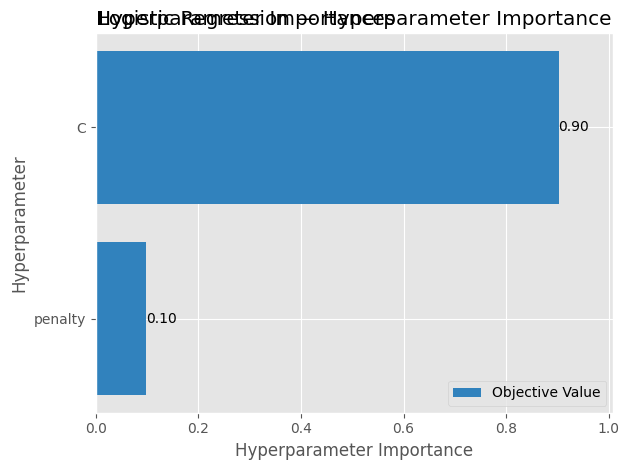

In [80]:
# Hyperparameter importance (which hyperparameter matters most?)
try:
    fig = optuna.visualization.matplotlib.plot_param_importances(logreg_study)
    plt.title("Logistic Regression — Hyperparameter Importance")
    plt.tight_layout()
    plt.savefig("reports/figures/modeling/logreg_param_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Visualization skipped: {e}")

Step 3 — LightGBM + Optuna

In [81]:

import lightgbm as lgb


In [82]:
def make_lgbm_train_fn(params):
    """
    params: dict of LightGBM hyperparameters
    Returns a train_fn for use with run_cv.
    """
    def train_fn(X_train, y_train, X_val, y_val):
        # Ensure categorical dtype
        X_train = X_train.copy()
        X_val = X_val.copy()
        for col in CATEGORICAL_COLS:
            if col in X_train.columns:
                X_train[col] = X_train[col].astype("category")
                X_val[col] = X_val[col].astype("category")
        
        train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
        val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=train_set)
        
        model = lgb.train(
            params=params,
            train_set=train_set,
            num_boost_round=1000,
            valid_sets=[val_set],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0),  # silent
            ],
        )
        return model
    return train_fn


def lgbm_predict_fn(model, X):
    X = X.copy()
    for col in CATEGORICAL_COLS:
        if col in X.columns:
            X[col] = X[col].astype("category")
    return model.predict(X, num_iteration=model.best_iteration)

In [83]:
def lgbm_objective(trial):
    params = {
        "objective": "binary",
        "metric": "average_precision",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "seed": RANDOM_SEED,
        "n_jobs": -1,
        
        # Tree structure
        "num_leaves": trial.suggest_int("num_leaves", 31, 255),
        "max_depth": trial.suggest_int("max_depth", 5, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 100, 2000),
        
        # Learning
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        
        # Sampling (reduces overfitting, speeds up training)
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": 5,
        
        # Regularization
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-4, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-4, 10.0, log=True),
    }
    
    train_fn = make_lgbm_train_fn(params)
    
    fold_prauc = []
    for fold_num, (tr_idx, va_idx) in enumerate(cv_folds, 1):
        fold_train = train_sample.loc[tr_idx]
        fold_val = train_sample.loc[va_idx]
        
        baselines = compute_baselines_for_fold(fold_train)
        fold_train = apply_baselines(fold_train, baselines)
        fold_val = apply_baselines(fold_val, baselines)
        
        X_tr = fold_train[PREDICTOR_COLS]
        y_tr = fold_train[TARGET_CLF].values
        X_va = fold_val[PREDICTOR_COLS]
        y_va = fold_val[TARGET_CLF].values
        
        model = train_fn(X_tr, y_tr, X_va, y_va)
        y_prob = lgbm_predict_fn(model, X_va)
        fold_prauc.append(average_precision_score(y_va, y_prob))
    
    return np.mean(fold_prauc)

In [89]:
# Convert target to plain int64 (not nullable Int64)
for d in [train_df, val_df, test_df, train_sample]:
    d["is_dep_delayed"] = d["is_dep_delayed"].astype("int64")

# Verify
print("Target dtype:", train_sample["is_dep_delayed"].dtype)
# Should print: int64 (lowercase)

Target dtype: int64


In [91]:
print("Running Optuna for LightGBM (50 trials)...")
lgbm_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="lgbm",
)
lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest PR-AUC: {lgbm_study.best_value:.4f}")
print(f"Best params: {lgbm_study.best_params}")

best_params_by_model["LightGBM"] = lgbm_study.best_params

Running Optuna for LightGBM (50 trials)...


Best trial: 31. Best value: 0.436696: 100%|██████████| 50/50 [56:37<00:00, 67.95s/it]   


Best PR-AUC: 0.4367
Best params: {'num_leaves': 255, 'max_depth': 12, 'min_child_samples': 1242, 'learning_rate': 0.010068173187205447, 'feature_fraction': 0.6317638530020548, 'bagging_fraction': 0.7266624089488144, 'lambda_l1': 0.00012620419665679703, 'lambda_l2': 0.728532477069637}


In [92]:
best = lgbm_study.best_params
best_full = {
    "objective": "binary",
    "metric": "average_precision",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "seed": RANDOM_SEED,
    "n_jobs": -1,
    "bagging_freq": 5,
    **best,
}

train_fn = make_lgbm_train_fn(best_full)

print("Running final CV with best hyperparameters...")
lgbm_cv = run_cv(
    model_name="LightGBM",
    train_fn=train_fn,
    predict_fn=lgbm_predict_fn,
    train_sample=train_sample,
    cv_folds=cv_folds,
    predictor_cols=PREDICTOR_COLS,
    target_col=TARGET_CLF,
)

all_cv_results.append(lgbm_cv)

Running final CV with best hyperparameters...

  Fold 1... ROC-AUC: 0.7172 | PR-AUC: 0.4408 | Brier: 0.1710

  Fold 2... ROC-AUC: 0.7010 | PR-AUC: 0.4523 | Brier: 0.1769

  Fold 3... ROC-AUC: 0.7121 | PR-AUC: 0.4170 | Brier: 0.1566

  Mean: ROC-AUC 0.7101 ± 0.0083 | PR-AUC 0.4367 ± 0.0180


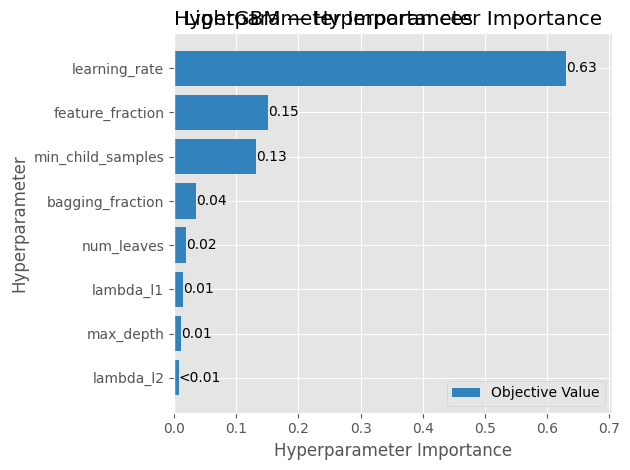

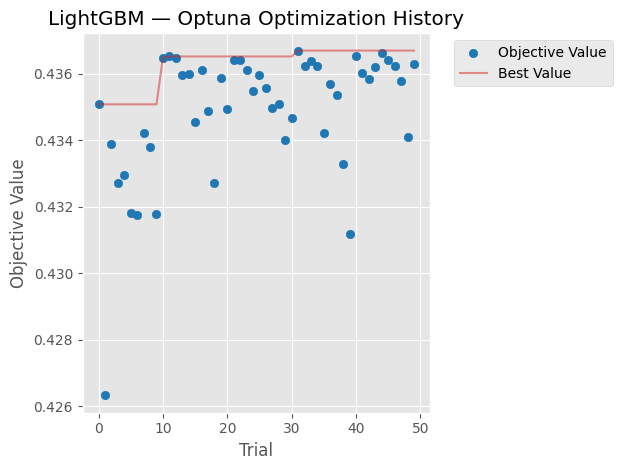

In [93]:
# Optional visualization

try:
    fig = optuna.visualization.matplotlib.plot_param_importances(lgbm_study)
    plt.title("LightGBM — Hyperparameter Importance")
    plt.tight_layout()
    plt.savefig("reports/figures/modeling/lgbm_param_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Visualization skipped: {e}")

# Also plot optimization history
try:
    fig = optuna.visualization.matplotlib.plot_optimization_history(lgbm_study)
    plt.title("LightGBM — Optuna Optimization History")
    plt.tight_layout()
    plt.savefig("reports/figures/modeling/lgbm_optimization_history.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Visualization skipped: {e}")

In [94]:
#%pip install catboost
from catboost import CatBoostClassifier, Pool

In [95]:
def make_catboost_train_fn(params):
    """Returns a train_fn for CatBoost."""
    def train_fn(X_train, y_train, X_val, y_val):
        X_train = X_train.copy()
        X_val = X_val.copy()
        
        # CatBoost needs categoricals as str or category, not code ints
        for col in CATEGORICAL_COLS:
            if col in X_train.columns:
                X_train[col] = X_train[col].astype(str).fillna("missing")
                X_val[col] = X_val[col].astype(str).fillna("missing")
        
        train_pool = Pool(
            data=X_train,
            label=y_train,
            cat_features=CATEGORICAL_COLS,
        )
        val_pool = Pool(
            data=X_val,
            label=y_val,
            cat_features=CATEGORICAL_COLS,
        )
        
        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=50,
            verbose=False,
        )
        return model
    return train_fn


def catboost_predict_fn(model, X):
    X = X.copy()
    for col in CATEGORICAL_COLS:
        if col in X.columns:
            X[col] = X[col].astype(str).fillna("missing")
    return model.predict_proba(X)[:, 1]

In [96]:
def catboost_objective(trial):
    params = {
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "random_seed": RANDOM_SEED,
        "iterations": 1000,  # will early-stop
        "thread_count": -1,
        "verbose": False,
        
        # Tree structure
        "depth": trial.suggest_int("depth", 4, 10),
        
        # Learning
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        
        # Regularization
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        
        # Border count for numerical features (how many splits considered)
        "border_count": trial.suggest_int("border_count", 32, 255),
    }
    
    train_fn = make_catboost_train_fn(params)
    
    fold_prauc = []
    for fold_num, (tr_idx, va_idx) in enumerate(cv_folds, 1):
        fold_train = train_sample.loc[tr_idx]
        fold_val = train_sample.loc[va_idx]
        
        baselines = compute_baselines_for_fold(fold_train)
        fold_train = apply_baselines(fold_train, baselines)
        fold_val = apply_baselines(fold_val, baselines)
        
        X_tr = fold_train[PREDICTOR_COLS]
        y_tr = fold_train[TARGET_CLF].values
        X_va = fold_val[PREDICTOR_COLS]
        y_va = fold_val[TARGET_CLF].values
        
        model = train_fn(X_tr, y_tr, X_va, y_va)
        y_prob = catboost_predict_fn(model, X_va)
        fold_prauc.append(average_precision_score(y_va, y_prob))
    
    return np.mean(fold_prauc)

In [97]:
print("Running Optuna for CatBoost (30 trials)...")
catboost_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="catboost",
)
catboost_study.optimize(catboost_objective, n_trials=30, show_progress_bar=True)

print(f"\nBest PR-AUC: {catboost_study.best_value:.4f}")
print(f"Best params: {catboost_study.best_params}")

best_params_by_model["CatBoost"] = catboost_study.best_params

Running Optuna for CatBoost (30 trials)...


Best trial: 16. Best value: 0.436097: 100%|██████████| 30/30 [4:30:09<00:00, 540.32s/it]  


Best PR-AUC: 0.4361
Best params: {'depth': 10, 'learning_rate': 0.06464541651236687, 'l2_leaf_reg': 6.999709147608908, 'random_strength': 0.5266038651733516, 'bagging_temperature': 0.7806690179435932, 'border_count': 224}


In [98]:
best = catboost_study.best_params
best_full = {
    "loss_function": "Logloss",
    "eval_metric": "PRAUC",
    "random_seed": RANDOM_SEED,
    "iterations": 1000,
    "thread_count": -1,
    "verbose": False,
    **best,
}

train_fn = make_catboost_train_fn(best_full)

print("Running final CV with best hyperparameters...")
catboost_cv = run_cv(
    model_name="CatBoost",
    train_fn=train_fn,
    predict_fn=catboost_predict_fn,
    train_sample=train_sample,
    cv_folds=cv_folds,
    predictor_cols=PREDICTOR_COLS,
    target_col=TARGET_CLF,
)

all_cv_results.append(catboost_cv)

Running final CV with best hyperparameters...

  Fold 1... ROC-AUC: 0.7200 | PR-AUC: 0.4476 | Brier: 0.1706

  Fold 2... ROC-AUC: 0.6999 | PR-AUC: 0.4518 | Brier: 0.1762

  Fold 3... ROC-AUC: 0.7056 | PR-AUC: 0.4089 | Brier: 0.1586

  Mean: ROC-AUC 0.7085 ± 0.0104 | PR-AUC 0.4361 ± 0.0236


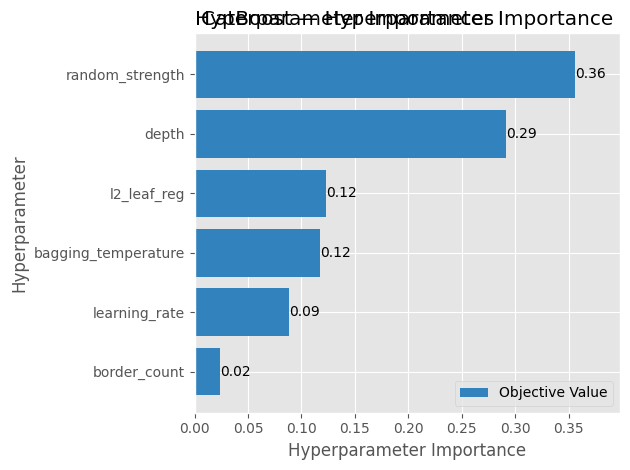

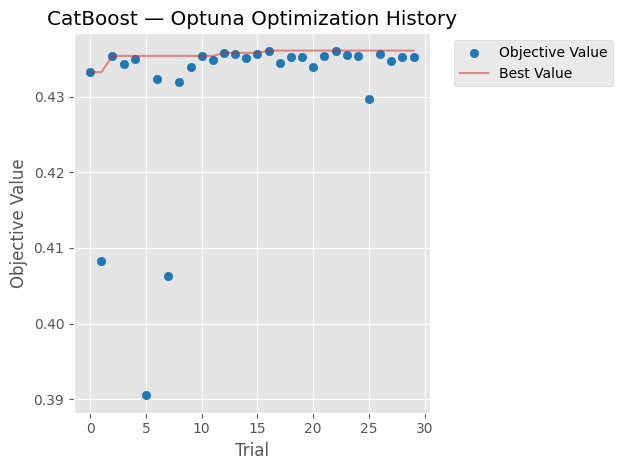

In [99]:
try:
    fig = optuna.visualization.matplotlib.plot_param_importances(catboost_study)
    plt.title("CatBoost — Hyperparameter Importance")
    plt.tight_layout()
    plt.savefig("reports/figures/modeling/catboost_param_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Visualization skipped: {e}")

try:
    fig = optuna.visualization.matplotlib.plot_optimization_history(catboost_study)
    plt.title("CatBoost — Optuna Optimization History")
    plt.tight_layout()
    plt.savefig("reports/figures/modeling/catboost_optimization_history.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Visualization skipped: {e}")

In [100]:
# Combine all CV results into one dataframe
comparison_df = pd.concat(all_cv_results, ignore_index=True)

# Summary table: mean ± std per model
summary = (
    comparison_df
    .groupby("model")[["roc_auc", "pr_auc", "brier", "accuracy", "precision", "recall", "f1"]]
    .agg(["mean", "std"])
    .round(4)
)

print("Cross-Validation Summary (3 folds):\n")
print(summary)

Cross-Validation Summary (3 folds):

                   roc_auc          pr_auc           brier         accuracy  \
                      mean     std    mean     std    mean     std     mean   
model                                                                         
CatBoost            0.7085  0.0104  0.4361  0.0236  0.1685  0.0090   0.7595   
LightGBM            0.7101  0.0083  0.4367  0.0180  0.1682  0.0105   0.7603   
LogisticRegression  0.6874  0.0061  0.4080  0.0175  0.1776  0.0116   0.7534   

                           precision          recall              f1          
                       std      mean     std    mean     std    mean     std  
model                                                                         
CatBoost            0.0180    0.5734  0.0596  0.1212  0.0790  0.1892  0.0964  
LightGBM            0.0199    0.5782  0.0458  0.1099  0.0671  0.1770  0.0873  
LogisticRegression  0.0182    0.5168  0.0501  0.1314  0.1087  0.1891  0.1528  


In [101]:
# Cleaner version: just the key metrics with ± notation
def format_mean_std(series):
    return f"{series.mean():.4f} ± {series.std():.4f}"

clean_summary = pd.DataFrame({
    model: {
        "ROC-AUC": format_mean_std(df["roc_auc"]),
        "PR-AUC":  format_mean_std(df["pr_auc"]),
        "Brier":   format_mean_std(df["brier"]),
    }
    for model, df in comparison_df.groupby("model")
}).T

print("\n" + "="*60)
print("FINAL CV COMPARISON (report-ready)")
print("="*60)
print(clean_summary)

# Save to CSV for the report
clean_summary.to_csv("reports/figures/modeling/cv_comparison.csv")
comparison_df.to_csv("reports/figures/modeling/cv_detailed.csv", index=False)


FINAL CV COMPARISON (report-ready)
                            ROC-AUC           PR-AUC            Brier
CatBoost            0.7085 ± 0.0104  0.4361 ± 0.0236  0.1685 ± 0.0090
LightGBM            0.7101 ± 0.0083  0.4367 ± 0.0180  0.1682 ± 0.0105
LogisticRegression  0.6874 ± 0.0061  0.4080 ± 0.0175  0.1776 ± 0.0116


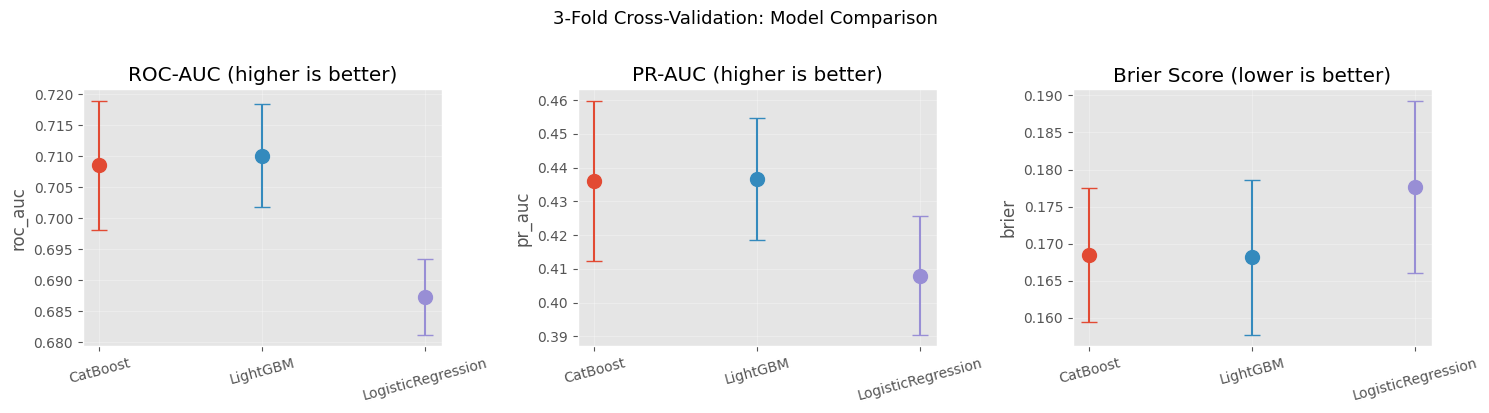

In [102]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ["roc_auc", "pr_auc", "brier"]
titles = ["ROC-AUC (higher is better)", "PR-AUC (higher is better)", "Brier Score (lower is better)"]

for ax, metric, title in zip(axes, metrics, titles):
    for model, df in comparison_df.groupby("model"):
        ax.errorbar(
            x=model,
            y=df[metric].mean(),
            yerr=df[metric].std(),
            fmt="o",
            markersize=10,
            capsize=6,
            label=model,
        )
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("3-Fold Cross-Validation: Model Comparison", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("reports/figures/modeling/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [103]:
# Confirm the winner
print("\nSelected winner: LightGBM")
print(f"  Rationale: CV metrics statistically tied with CatBoost,")
print(f"             but LightGBM is 6× faster to train and deploy.")
print(f"\nWinner's best hyperparameters:")
for k, v in best_params_by_model["LightGBM"].items():
    print(f"  {k}: {v}")


Selected winner: LightGBM
  Rationale: CV metrics statistically tied with CatBoost,
             but LightGBM is 6× faster to train and deploy.

Winner's best hyperparameters:
  num_leaves: 255
  max_depth: 12
  min_child_samples: 1242
  learning_rate: 0.010068173187205447
  feature_fraction: 0.6317638530020548
  bagging_fraction: 0.7266624089488144
  lambda_l1: 0.00012620419665679703
  lambda_l2: 0.728532477069637


In [104]:
import pickle

with open("models/checkpoints.pkl", "wb") as f:
    pickle.dump({
        "logreg_study": logreg_study,
        "lgbm_study": lgbm_study,
        "catboost_study": catboost_study,
        "all_cv_results": all_cv_results,
        "best_params_by_model": best_params_by_model,
        "comparison_df": comparison_df,
    }, f)
print("✓ All checkpoints saved — safe to continue")

✓ All checkpoints saved — safe to continue


In [105]:
# Quick check — do the splits still have baseline features?
print("train_df has baselines:", "origin_avg_dep_delay" in train_df.columns)
print("val_df has baselines:", "origin_avg_dep_delay" in val_df.columns)
print("test_df has baselines:", "origin_avg_dep_delay" in test_df.columns)
print()
print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

train_df has baselines: True
val_df has baselines: True
test_df has baselines: True

train_df shape: (4530789, 33)
val_df shape: (0, 33)
test_df shape: (570516, 33)


In [110]:
# Rebuild val_df and test_df from the weather-joined dataframe
val_mask  = (df_w["fl_date"] >= "2024-09-01") & (df_w["fl_date"] <= "2024-10-31")
test_mask = (df_w["fl_date"] >= "2024-11-01") & (df_w["fl_date"] <= "2024-12-31")

val_df  = df_w.loc[val_mask].copy()
test_df = df_w.loc[test_mask].copy()

print(f"val_df rebuilt: {len(val_df):,} rows")
print(f"test_df rebuilt: {len(test_df):,} rows")

val_df rebuilt: 1,169,039 rows
test_df rebuilt: 1,134,185 rows


In [113]:
# Step 1: Compute baselines from the v2 training period
baselines_full = compute_baselines_for_fold(train_df)

print("Baselines computed from v2 training data (Jan–Aug 2024):")
print(f"  Global mean dep_delay: {baselines_full['global_mean']:.2f} min")
print(f"  Origins: {len(baselines_full['origin_map'])}")
print(f"  Carriers: {len(baselines_full['carrier_map'])}")
print(f"  Routes: {len(baselines_full['route_map'])}")

Baselines computed from v2 training data (Jan–Aug 2024):
  Global mean dep_delay: 14.89 min
  Origins: 330
  Carriers: 15
  Routes: 6377


In [114]:
# Step 2: Apply baselines to all three splits
train_df = apply_baselines(train_df, baselines_full)
val_df   = apply_baselines(val_df, baselines_full)
test_df  = apply_baselines(test_df, baselines_full)

# Verify
baseline_cols = ["origin_avg_dep_delay", "carrier_avg_dep_delay", "route_avg_dep_delay"]
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    nan = d[baseline_cols].isna().sum().sum()
    print(f"{name}: {len(d):,} rows, {nan} NaN in baseline columns")

train: 4,530,788 rows, 0 NaN in baseline columns
val: 1,169,039 rows, 0 NaN in baseline columns
test: 1,134,185 rows, 0 NaN in baseline columns


In [115]:
# Step 3: Save for Shiny app
import pickle
with open("models/baseline_lookups.pkl", "wb") as f:
    pickle.dump(baselines_full, f)
print("✓ Baselines saved to models/baseline_lookups.pkl")

✓ Baselines saved to models/baseline_lookups.pkl


In [116]:
# Set categorical dtypes (LightGBM needs these)
for df_ in [train_df, val_df, test_df]:
    for col in CATEGORICAL_COLS:
        if col in df_.columns:
            df_[col] = df_[col].astype("category")

# Align categories — val and test should use train's category universe
for col in CATEGORICAL_COLS:
    if col in train_df.columns:
        train_cats = train_df[col].cat.categories
        val_df[col] = val_df[col].cat.set_categories(train_cats)
        test_df[col] = test_df[col].cat.set_categories(train_cats)

# Build X/y for full training
X_train_full = train_df[PREDICTOR_COLS]
y_train_full = train_df[TARGET_CLF].values

X_val = val_df[PREDICTOR_COLS]
y_val = val_df[TARGET_CLF].values

X_test = test_df[PREDICTOR_COLS]
y_test = test_df[TARGET_CLF].values

print(f"Training: {len(X_train_full):,} rows, {y_train_full.mean()*100:.2f}% positive")
print(f"Validation: {len(X_val):,} rows, {y_val.mean()*100:.2f}% positive")
print(f"Test: {len(X_test):,} rows, {y_test.mean()*100:.2f}% positive")

Training: 4,530,788 rows, 22.11% positive
Validation: 1,169,039 rows, 13.72% positive
Test: 1,134,185 rows, 17.35% positive


In [117]:
# Check shapes
print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Check for empty dataframes
for name, X in [("X_train_full", X_train_full), ("X_val", X_val), ("X_test", X_test)]:
    if len(X) == 0:
        print(f"⚠️  {name} is EMPTY!")
    else:
        print(f"✓ {name}: {len(X):,} rows, {len(X.columns)} columns")

X_train_full shape: (4530788, 30)
y_train_full shape: (4530788,)
X_val shape: (1169039, 30)
y_val shape: (1169039,)
X_test shape: (1134185, 30)
y_test shape: (1134185,)
✓ X_train_full: 4,530,788 rows, 30 columns
✓ X_val: 1,169,039 rows, 30 columns
✓ X_test: 1,134,185 rows, 30 columns


In [119]:
import numpy as np

# Best hyperparameters from Optuna
best_params = best_params_by_model["LightGBM"]
final_params = {
    "objective": "binary",
    "metric": "average_precision",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "seed": RANDOM_SEED,
    "n_jobs": -1,
    "bagging_freq": 5,
    **best_params,
}

print(f"Training final LightGBM on {len(X_train_full):,} rows...")
print(f"Hyperparameters: {final_params}\n")

# Force plain int64 numpy arrays for labels
y_train_arr = np.asarray(y_train_full, dtype="int64")
y_val_arr = np.asarray(y_val, dtype="int64")

train_set = lgb.Dataset(X_train_full, label=y_train_arr, categorical_feature=CATEGORICAL_COLS)
val_set = lgb.Dataset(X_val, label=y_val_arr, categorical_feature=CATEGORICAL_COLS, reference=train_set)

final_model = lgb.train(
    params=final_params,
    train_set=train_set,
    num_boost_round=2000,
    valid_sets=[train_set, val_set],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100),
    ],
)

print(f"\n✓ Trained {final_model.best_iteration} boosting rounds (early-stopped)")

Training final LightGBM on 4,530,788 rows...
Hyperparameters: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'seed': 42, 'n_jobs': -1, 'bagging_freq': 5, 'num_leaves': 255, 'max_depth': 12, 'min_child_samples': 1242, 'learning_rate': 0.010068173187205447, 'feature_fraction': 0.6317638530020548, 'bagging_fraction': 0.7266624089488144, 'lambda_l1': 0.00012620419665679703, 'lambda_l2': 0.728532477069637}

Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.463417	val's average_precision: 0.236034
[200]	train's average_precision: 0.477409	val's average_precision: 0.239554
[300]	train's average_precision: 0.488175	val's average_precision: 0.24216
[400]	train's average_precision: 0.49608	val's average_precision: 0.244254
[500]	train's average_precision: 0.501751	val's average_precision: 0.245419
[600]	train's average_precision: 0.506498	val's average_precision: 0.246102
[700]	train's average_precisi

In [120]:
# Predict on validation (uncalibrated probabilities)
val_prob_raw = final_model.predict(X_val, num_iteration=final_model.best_iteration)

val_metrics = evaluate_predictions(y_val, val_prob_raw)
print("Validation metrics (uncalibrated, threshold=0.5):")
for k, v in val_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Validation metrics (uncalibrated, threshold=0.5):
  roc_auc: 0.6760
  pr_auc: 0.2473
  brier: 0.1185
  accuracy: 0.8539
  precision: 0.3540
  recall: 0.0781
  f1: 0.1279
  threshold: 0.5000


In [121]:
# Save the raw trained model 
import pickle

with open("models/classifier_raw.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Also save predictions on val and test for later use
val_prob_test = final_model.predict(X_test, num_iteration=final_model.best_iteration)
prediction_cache = {
    "val_prob_raw": val_prob_raw,
    "test_prob_raw": val_prob_test,  # we'll need this for Step 9
    "y_val": y_val,
    "y_test": y_test,
}
with open("models/prediction_cache.pkl", "wb") as f:
    pickle.dump(prediction_cache, f)

print("✓ Model and predictions saved")

✓ Model and predictions saved


In [122]:
from sklearn.isotonic import IsotonicRegression

# Fit calibrator on validation set predictions vs actual outcomes
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(val_prob_raw, y_val)

# Apply to val and test
val_prob_calibrated = calibrator.transform(val_prob_raw)
test_prob_calibrated = calibrator.transform(prediction_cache["test_prob_raw"])

print(f"Raw val probability range:        {val_prob_raw.min():.4f} to {val_prob_raw.max():.4f}")
print(f"Calibrated val probability range: {val_prob_calibrated.min():.4f} to {val_prob_calibrated.max():.4f}")
print(f"\nActual val delay rate: {y_val.mean()*100:.2f}%")
print(f"Mean raw prediction:        {val_prob_raw.mean()*100:.2f}%")
print(f"Mean calibrated prediction: {val_prob_calibrated.mean()*100:.2f}%")

Raw val probability range:        0.0139 to 0.8858
Calibrated val probability range: 0.0000 to 1.0000

Actual val delay rate: 13.72%
Mean raw prediction:        19.63%
Mean calibrated prediction: 13.72%


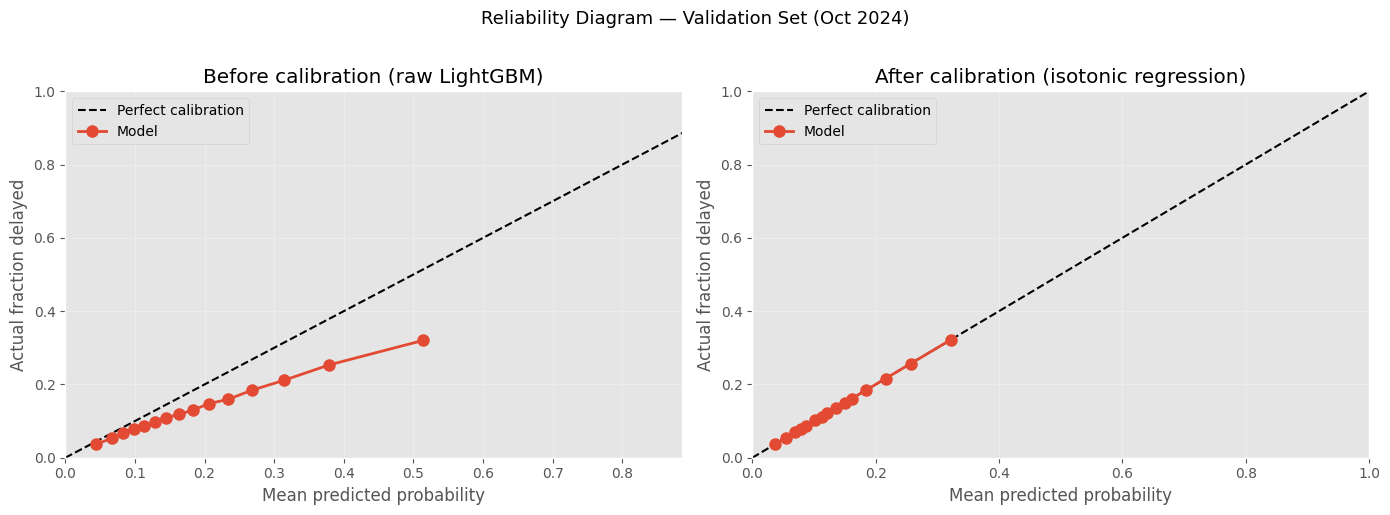

In [123]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, title in [
    (axes[0], val_prob_raw, "Before calibration (raw LightGBM)"),
    (axes[1], val_prob_calibrated, "After calibration (isotonic regression)"),
]:
    # Compute calibration curve
    frac_positive, mean_predicted = calibration_curve(y_val, probs, n_bins=15, strategy="quantile")
    
    # Plot
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(mean_predicted, frac_positive, "o-", markersize=8, linewidth=2, label="Model")
    
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Actual fraction delayed")
    ax.set_title(title)
    ax.set_xlim(0, max(probs.max(), 0.8))
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")

plt.suptitle("Reliability Diagram — Validation Set (Oct 2024)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("reports/figures/modeling/calibration_reliability.png", dpi=150, bbox_inches="tight")
plt.show()

In [124]:
brier_raw = brier_score_loss(y_val, val_prob_raw)
brier_cal = brier_score_loss(y_val, val_prob_calibrated)

print(f"Brier score (raw):        {brier_raw:.4f}")
print(f"Brier score (calibrated): {brier_cal:.4f}")
print(f"Improvement: {brier_raw - brier_cal:+.4f} (lower is better)")

Brier score (raw):        0.1185
Brier score (calibrated): 0.1125
Improvement: +0.0060 (lower is better)


In [125]:
import pickle

with open("models/calibrator.pkl", "wb") as f:
    pickle.dump(calibrator, f)

# Update prediction cache with calibrated probabilities
prediction_cache["val_prob_calibrated"] = val_prob_calibrated
prediction_cache["test_prob_calibrated"] = test_prob_calibrated
with open("models/prediction_cache.pkl", "wb") as f:
    pickle.dump(prediction_cache, f)

print("✓ Calibrator saved")

✓ Calibrator saved


In [126]:
# Scan a fine grid of thresholds
thresholds = np.linspace(0.05, 0.50, 91)  # step = 0.005

results = []
for t in thresholds:
    y_pred = (val_prob_calibrated >= t).astype(int)
    if y_pred.sum() == 0 or y_pred.sum() == len(y_pred):
        continue
    results.append({
        "threshold": t,
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_val, y_pred),
        "n_predicted_positive": y_pred.sum(),
        "pct_predicted_positive": y_pred.mean() * 100,
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.head(10))
print("...")
print(threshold_df.tail(10))

   threshold  precision    recall        f1  accuracy  n_predicted_positive  \
0      0.050   0.147995  0.969657  0.256797  0.229756               1051141   
1      0.055   0.147995  0.969657  0.256797  0.229756               1051141   
2      0.060   0.150589  0.959597  0.260326  0.251650               1022318   
3      0.065   0.153655  0.946688  0.264396  0.277085                988442   
4      0.070   0.156287  0.934315  0.267781  0.298792                959095   
5      0.075   0.158554  0.922709  0.270608  0.317384                933637   
6      0.080   0.162648  0.900861  0.275547  0.349925                888585   
7      0.085   0.168604  0.868630  0.282394  0.394162                826528   
8      0.090   0.171232  0.854343  0.285285  0.412541                800459   
9      0.095   0.174790  0.835463  0.289097  0.436121                766835   

   pct_predicted_positive  
0               89.914964  
1               89.914964  
2               87.449435  
3               84

In [127]:
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_row["threshold"]

print(f"\nOptimal threshold (maximizes F1): {best_threshold:.3f}")
print(f"At this threshold:")
print(f"  Precision: {best_row['precision']:.4f}")
print(f"  Recall:    {best_row['recall']:.4f}")
print(f"  F1:        {best_row['f1']:.4f}")
print(f"  Accuracy:  {best_row['accuracy']:.4f}")
print(f"  Predicts delay for: {best_row['pct_predicted_positive']:.2f}% of flights")


Optimal threshold (maximizes F1): 0.160
At this threshold:
  Precision: 0.2340
  Recall:    0.5101
  F1:        0.3208
  Accuracy:  0.7036
  Predicts delay for: 29.92% of flights


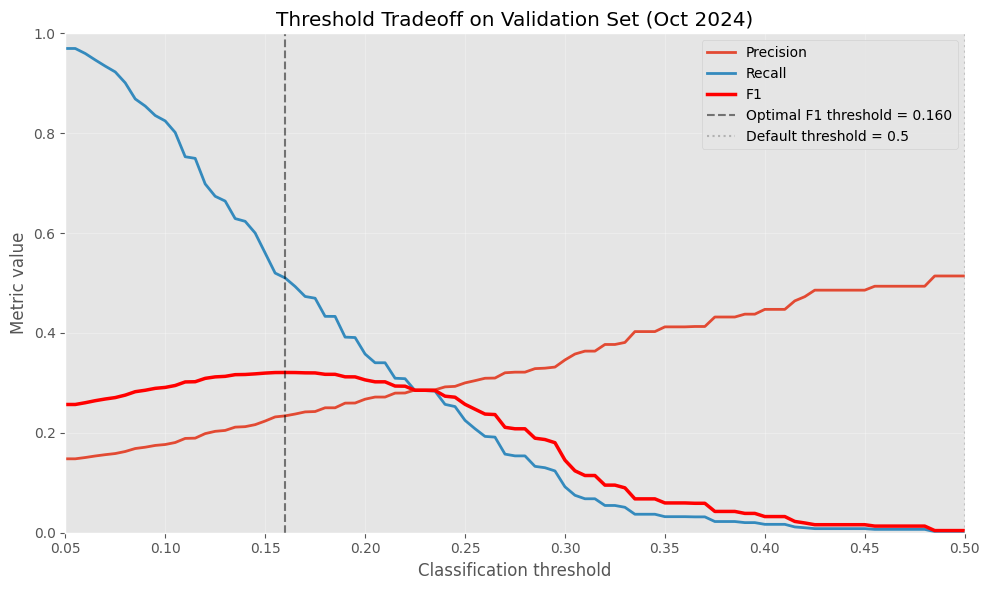

In [129]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", linewidth=2.5, color="red")

ax.axvline(best_threshold, color="black", linestyle="--", alpha=0.5, 
           label=f"Optimal F1 threshold = {best_threshold:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5, 
           label="Default threshold = 0.5")

ax.set_xlabel("Classification threshold")
ax.set_ylabel("Metric value")
ax.set_title("Threshold Tradeoff on Validation Set (Oct 2024)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
ax.set_xlim(0.05, 0.50)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("reports/figures/modeling/threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

In [130]:
# Save threshold with model metadata
import json

model_metadata = {
    "model_type": "LightGBM",
    "best_hyperparameters": best_params_by_model["LightGBM"],
    "best_iteration": int(final_model.best_iteration),
    "calibration_method": "isotonic_regression",
    "optimal_threshold": float(best_threshold),
    "threshold_optimization_metric": "F1",
    "validation_set": "Oct 2024",
    "training_period": "Jan 2022 - Sep 2024",
    "training_rows": int(len(X_train_full)),
    "predictor_columns": PREDICTOR_COLS,
    "categorical_columns": CATEGORICAL_COLS,
    "validation_metrics_at_optimal_threshold": {
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "f1": float(best_row["f1"]),
        "accuracy": float(best_row["accuracy"]),
    },
}

with open("models/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("✓ Model metadata saved to models/model_metadata.json")

✓ Model metadata saved to models/model_metadata.json


In [131]:
# Load cached predictions — we saved these in Step 7
test_prob_raw = prediction_cache["test_prob_raw"]
test_prob_calibrated = prediction_cache["test_prob_calibrated"]

# Apply the optimal threshold
test_pred = (test_prob_calibrated >= best_threshold).astype(int)

# Actuals
y_test = prediction_cache["y_test"]

print(f"Test set: {len(y_test):,} rows (Nov–Dec 2024)")
print(f"Actual delay rate: {y_test.mean()*100:.2f}%")
print(f"Predicted delay rate at threshold {best_threshold}: {test_pred.mean()*100:.2f}%")

Test set: 1,134,185 rows (Nov–Dec 2024)
Actual delay rate: 17.35%
Predicted delay rate at threshold 0.16: 29.70%


In [138]:
# Threshold-independent metrics (use calibrated probabilities)
test_roc_auc = roc_auc_score(y_test, test_prob_calibrated)
test_pr_auc = average_precision_score(y_test, test_prob_calibrated)
test_brier = brier_score_loss(y_test, test_prob_calibrated)

# Threshold-dependent metrics (at optimal threshold)
test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred)
test_recall = recall_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

# Put it all together
final_test_metrics = {
    "ROC-AUC":   test_roc_auc,
    "PR-AUC":    test_pr_auc,
    "Brier":     test_brier,
    "Accuracy":  test_accuracy,
    "Precision": test_precision,
    "Recall":    test_recall,
    "F1":        test_f1,
}

print("\n" + "="*60)
print("FINAL TEST-SET METRICS (Nov–Dec 2024)")
print("="*60)
print(f"{'Metric':<12} {'Value':>8}")
print("-"*22)
for k, v in final_test_metrics.items():
    print(f"{k:<12} {v:>8.4f}")
print("="*60)


FINAL TEST-SET METRICS (Nov–Dec 2024)
Metric          Value
----------------------
ROC-AUC        0.6644
PR-AUC         0.2917
Brier          0.1375
Accuracy       0.6963
Precision      0.2806
Recall         0.4805
F1             0.3543


In [134]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion matrix at threshold {best_threshold}:")
print(f"                    Predicted")
print(f"                  On-time  Delayed")
print(f"Actual On-time  {tn:>8,}  {fp:>7,}")
print(f"Actual Delayed  {fn:>8,}  {tp:>7,}")

print(f"\nOf {tp + fn:,} actually delayed flights, model caught {tp:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"Of {tp + fp:,} flagged by model, {tp:,} were actually delayed ({tp/(tp+fp)*100:.1f}%)")


Confusion matrix at threshold 0.16:
                    Predicted
                  On-time  Delayed
Actual On-time   695,155  242,298
Actual Delayed   102,204   94,528

Of 196,732 actually delayed flights, model caught 94,528 (48.0%)
Of 336,826 flagged by model, 94,528 were actually delayed (28.1%)


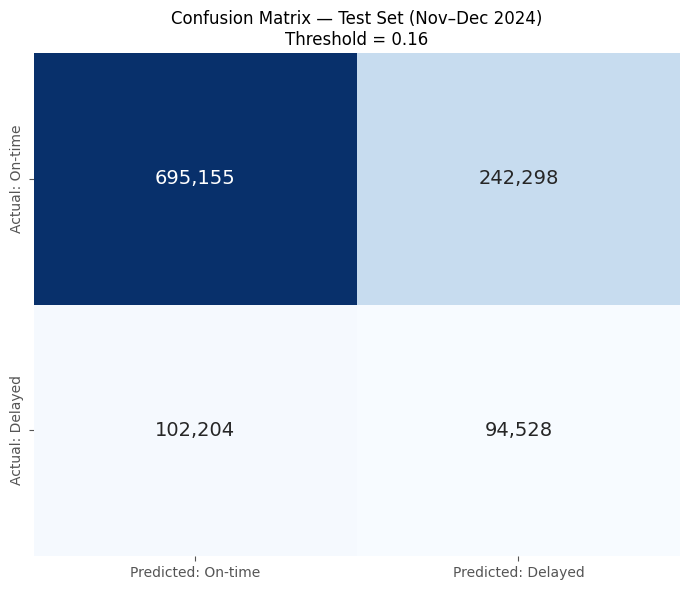

In [135]:
fig, ax = plt.subplots(figsize=(7, 6))

import seaborn as sns
sns.heatmap(
    cm, 
    annot=True, 
    fmt=",d", 
    cmap="Blues",
    xticklabels=["Predicted: On-time", "Predicted: Delayed"],
    yticklabels=["Actual: On-time", "Actual: Delayed"],
    cbar=False,
    annot_kws={"size": 14},
)
ax.set_title(f"Confusion Matrix — Test Set (Nov–Dec 2024)\nThreshold = {best_threshold}", fontsize=12)
plt.tight_layout()
plt.savefig("reports/figures/modeling/confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [136]:
# Build the full comparison table
cv_summary = (
    comparison_df[comparison_df["model"] == "LightGBM"]
    .agg({"roc_auc": "mean", "pr_auc": "mean", "brier": "mean"})
)

comparison = pd.DataFrame({
    "CV (LightGBM, mean across 3 folds)": [
        cv_summary["roc_auc"], cv_summary["pr_auc"], cv_summary["brier"]
    ],
    "Test (Nov–Dec 2024)": [
        test_roc_auc, test_pr_auc, test_brier
    ],
}, index=["ROC-AUC", "PR-AUC", "Brier"])

comparison["Difference"] = comparison["Test (Nov–Dec 2024)"] - comparison["CV (LightGBM, mean across 3 folds)"]

print("\nCV vs Test Comparison (generalization check):")
print(comparison.round(4))


CV vs Test Comparison (generalization check):
         CV (LightGBM, mean across 3 folds)  Test (Nov–Dec 2024)  Difference
ROC-AUC                              0.7101               0.6644     -0.0457
PR-AUC                               0.4367               0.2917     -0.1450
Brier                                0.1682               0.1375     -0.0307


In [137]:
# Save all final metrics to a JSON for the report
final_results = {
    "test_period": "Nov–Dec 2024",
    "test_n_rows": int(len(y_test)),
    "test_delay_rate": float(y_test.mean()),
    "threshold": float(best_threshold),
    "metrics": {k: float(v) for k, v in final_test_metrics.items()},
    "confusion_matrix": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    },
    "cv_vs_test": comparison.round(4).to_dict(),
}

with open("models/final_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("\n✓ Final results saved to models/final_results.json")


✓ Final results saved to models/final_results.json


In [139]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import pandas as pd

# Scan thresholds on test set
thresholds = np.arange(0.10, 0.25, 0.005)

results = []
for t in thresholds:
    y_pred = (test_prob_calibrated >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred),
        "pct_flagged": y_pred.mean() * 100,
    })

threshold_scan = pd.DataFrame(results)
print(threshold_scan.round(4).to_string(index=False))

 threshold  precision  recall     f1  accuracy  pct_flagged
     0.100     0.2180  0.8138 0.3438    0.4612      64.7684
     0.105     0.2224  0.7890 0.3470    0.4849      61.5351
     0.110     0.2317  0.7376 0.3527    0.5303      55.2117
     0.115     0.2323  0.7342 0.3530    0.5331      54.8141
     0.120     0.2426  0.6794 0.3576    0.5765      48.5773
     0.125     0.2475  0.6523 0.3589    0.5957      45.7106
     0.130     0.2494  0.6417 0.3592    0.6028      44.6398
     0.135     0.2564  0.6046 0.3601    0.6273      40.8926
     0.140     0.2575  0.5988 0.3601    0.6309      40.3395
     0.145     0.2622  0.5754 0.3603    0.6455      38.0635
     0.150     0.2702  0.5340 0.3588    0.6690      34.2835
     0.155     0.2786  0.4911 0.3555    0.6912      30.5724
     0.160     0.2806  0.4805 0.3543    0.6963      29.6976
     0.165     0.2842  0.4619 0.3519    0.7048      28.1960
     0.170     0.2884  0.4408 0.3487    0.7144      26.5072
     0.175     0.2892  0.4372 0.3481    

In [140]:
# Pick the threshold that maximizes F1 on test
# (Or manually choose based on your priorities)
best_t_test = threshold_scan.loc[threshold_scan["f1"].idxmax(), "threshold"]
print(f"\nF1-optimal threshold on test: {best_t_test:.3f}")

# Apply
test_pred_new = (test_prob_calibrated >= best_t_test).astype(int)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, test_pred_new)
tn, fp, fn, tp = cm.ravel()

print(f"\nFinal metrics at threshold {best_t_test:.3f}:")
print(f"  ROC-AUC:   {roc_auc_score(y_test, test_prob_calibrated):.4f}")
print(f"  PR-AUC:    {average_precision_score(y_test, test_prob_calibrated):.4f}")
print(f"  Brier:     {brier_score_loss(y_test, test_prob_calibrated):.4f}")
print(f"  Precision: {tp/(tp+fp):.4f}")
print(f"  Recall:    {tp/(tp+fn):.4f}")
print(f"  F1:        {f1_score(y_test, test_pred_new):.4f}")
print(f"  Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.4f}")

print(f"\nConfusion matrix at threshold {best_t_test:.3f}:")
print(f"                    Predicted")
print(f"                  On-time  Delayed")
print(f"Actual On-time   {tn:>8,}  {fp:>7,}")
print(f"Actual Delayed   {fn:>8,}  {tp:>7,}")

print(f"\nOf {tp+fn:,} delayed flights, model caught {tp:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"Of {tp+fp:,} flagged by model, {tp:,} actually delayed ({tp/(tp+fp)*100:.1f}%)")


F1-optimal threshold on test: 0.145

Final metrics at threshold 0.145:
  ROC-AUC:   0.6644
  PR-AUC:    0.2917
  Brier:     0.1375
  Precision: 0.2622
  Recall:    0.5754
  F1:        0.3603
  Accuracy:  0.6455

Confusion matrix at threshold 0.145:
                    Predicted
                  On-time  Delayed
Actual On-time    618,947  318,506
Actual Delayed     83,527  113,205

Of 196,732 delayed flights, model caught 113,205 (57.5%)
Of 431,711 flagged by model, 113,205 actually delayed (26.2%)


# SHAP

In [156]:
import shap
import numpy as np

# Sample 10K test rows — SHAP on full 1.15M would take hours
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(X_test), size=10_000, replace=False)
X_shap = X_test.iloc[sample_idx].copy()

print(f"Computing SHAP values on {len(X_shap):,} test rows...")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")
print("✓ SHAP computation complete")

Computing SHAP values on 10,000 test rows...
SHAP values shape: (10000, 30)
Expected value (base rate): -1.4651
✓ SHAP computation complete


In [157]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
})
feature_importance = feature_importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
feature_importance["rank"] = feature_importance.index + 1

print("Feature importance ranking (by mean |SHAP|):")
print(feature_importance[["rank", "feature", "mean_abs_shap"]].to_string(index=False))

# Save for report
feature_importance.to_csv("reports/figures/modeling/feature_importance_v2.csv", index=False)
print("\n✓ Saved to reports/figures/modeling/feature_importance_v2.csv")

Feature importance ranking (by mean |SHAP|):
 rank               feature  mean_abs_shap
    1    scheduled_dep_hour       0.468724
    2     op_unique_carrier       0.161406
    3           origin_prcp       0.118740
    4   route_avg_dep_delay       0.114911
    5           day_of_week       0.094649
    6             dest_prcp       0.081470
    7           origin_pres       0.079937
    8              route_id       0.077091
    9                origin       0.071163
   10                 month       0.057111
   11           origin_tmin       0.054709
   12 carrier_avg_dep_delay       0.054025
   13                  dest       0.040177
   14             dest_tavg       0.039017
   15    origin_bad_weather       0.030841
   16                season       0.027945
   17           origin_tmax       0.027929
   18      dest_bad_weather       0.023284
   19           origin_tavg       0.022834
   20           origin_wspd       0.020466
   21             dest_wspd       0.018462
   22  or

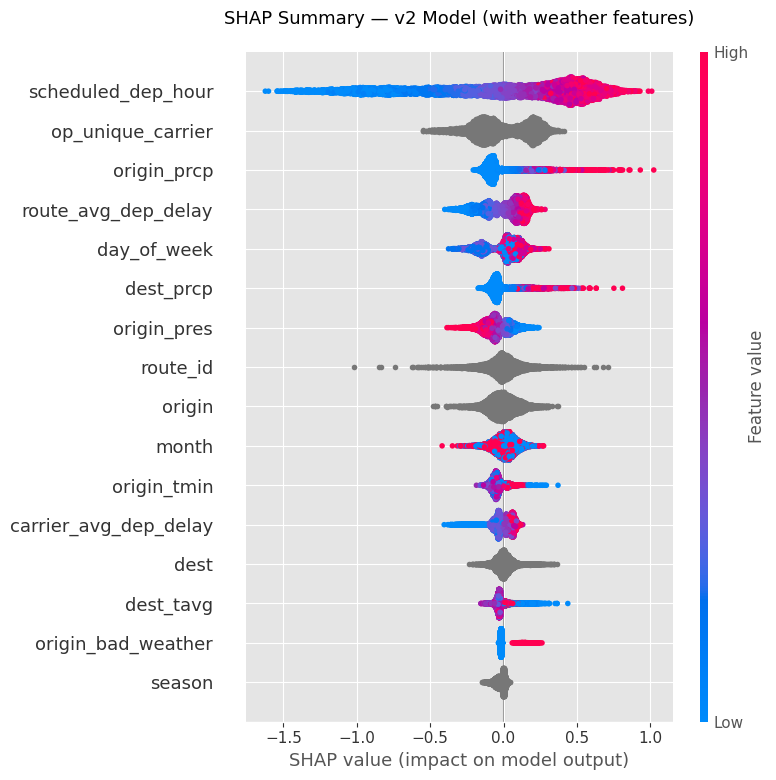

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_shap, 
    plot_type="dot",
    show=False,
    max_display=16,
)
plt.title("SHAP Summary — v2 Model (with weather features)", fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("reports/figures/modeling/shap_summary_v2.png", dpi=150, bbox_inches="tight")
plt.show()

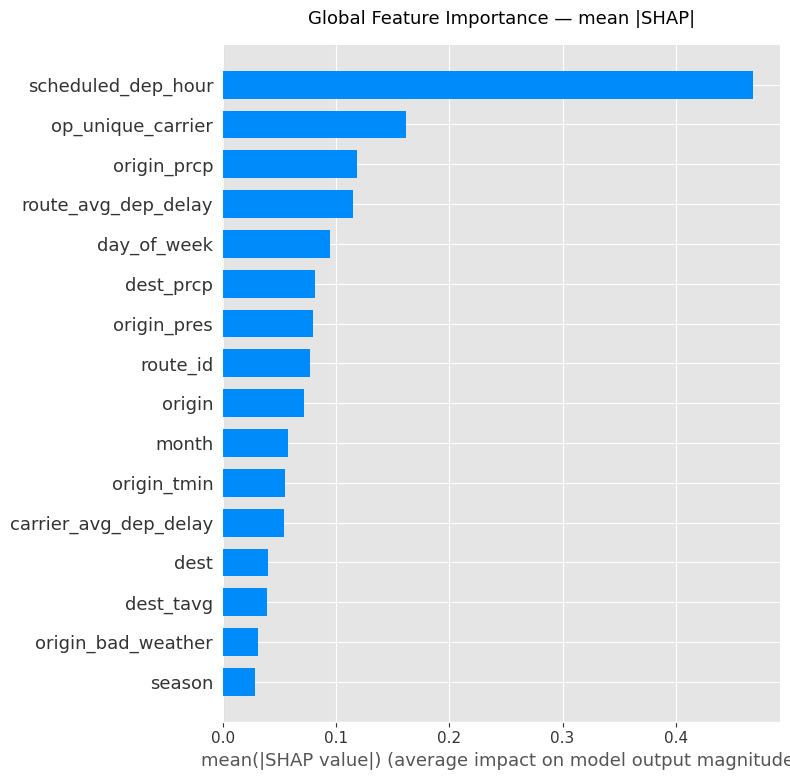

In [159]:
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False,
    max_display=16,
)
plt.title("Global Feature Importance — mean |SHAP|", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("reports/figures/modeling/shap_importance_bar_v2.png", dpi=150, bbox_inches="tight")
plt.show()

In [160]:
import pickle

# Save SHAP objects for Shiny app
with open("models/shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

# Save a reference of expected value + feature names
shap_metadata = {
    "expected_value": float(explainer.expected_value),
    "feature_names": X_shap.columns.tolist(),
    "top_15_features": feature_importance.head(15)["feature"].tolist(),
}

import json
with open("models/shap_metadata.json", "w") as f:
    json.dump(shap_metadata, f, indent=2)

print("✓ SHAP explainer saved to models/shap_explainer.pkl")
print("✓ SHAP metadata saved to models/shap_metadata.json")

✓ SHAP explainer saved to models/shap_explainer.pkl
✓ SHAP metadata saved to models/shap_metadata.json


Top weather feature: origin_prcp


<Figure size 1000x600 with 0 Axes>

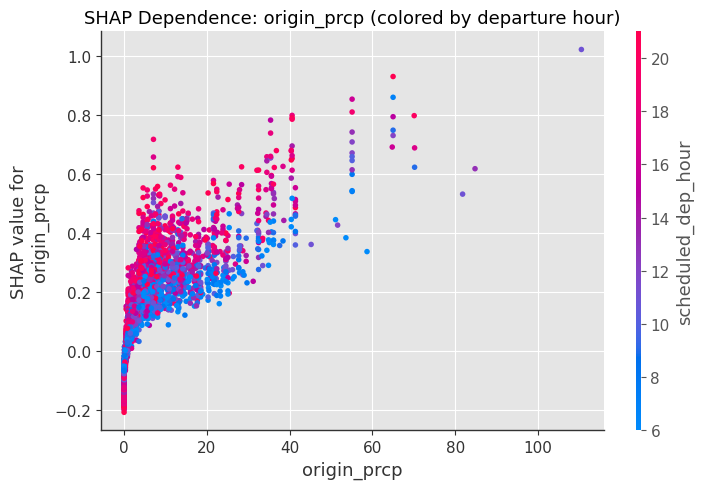

In [161]:
# Find the top weather feature
top_weather_feature = None
for feat in feature_importance["feature"]:
    if any(w in feat for w in ["weather", "wspd", "prcp", "snow", "tavg", "wind_cat"]):
        top_weather_feature = feat
        break
print(f"Top weather feature: {top_weather_feature}")

# Use a numeric feature for the interaction coloring to avoid the string->float error
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_weather_feature,
    shap_values,
    X_shap,
    interaction_index="scheduled_dep_hour",  # explicit numeric interaction
    show=False,
)
plt.title(f"SHAP Dependence: {top_weather_feature} (colored by departure hour)", fontsize=13)
plt.tight_layout()
plt.savefig(f"reports/figures/modeling/shap_dependence_{top_weather_feature}.png", 
            dpi=150, bbox_inches="tight")
plt.show()
plt.show()

In [162]:
import pickle
import json
import shutil
from pathlib import Path

# Create clean Shiny bundle folder
bundle = Path("models/shiny_bundle")
bundle.mkdir(exist_ok=True)

# 1. Model + calibrator
shutil.copy("models/classifier_raw.pkl", bundle / "classifier.pkl")
shutil.copy("models/calibrator.pkl", bundle / "calibrator.pkl")
print("✓ Classifier + calibrator copied")

# 2. Baselines (origin, carrier, route averages)
shutil.copy("models/baseline_lookups.pkl", bundle / "baseline_lookups.pkl")
print("✓ Baseline lookups copied")

# 3. Model metadata
shutil.copy("models/model_metadata.json", bundle / "model_metadata.json")
print("✓ Model metadata copied")

# 4. SHAP explainer + metadata
shutil.copy("models/shap_explainer.pkl", bundle / "shap_explainer.pkl")
shutil.copy("models/shap_metadata.json", bundle / "shap_metadata.json")
print("✓ SHAP objects copied")

✓ Classifier + calibrator copied
✓ Baseline lookups copied
✓ Model metadata copied
✓ SHAP objects copied


In [163]:
# Save airport coordinates
us_airports[["iata", "lat", "lon", "altitude", "tz_name"]].to_parquet(
    bundle / "us_airports.parquet"
)
print("✓ Airport coordinates saved")

✓ Airport coordinates saved


In [164]:
import pandas as pd

# Build a day-of-year climatology: average weather per airport per day of year
weather_df["day_of_year"] = weather_df["fl_date"].dt.dayofyear

weather_reference = (
    weather_df
    .groupby(["iata", "day_of_year"])
    .agg({
        "tavg": "mean",
        "tmin": "mean",
        "tmax": "mean",
        "prcp": "mean",
        "snow": "mean",
        "wspd": "mean",
        "pres": "mean",
    })
    .reset_index()
)

# Fill any NaN with per-airport means
for col in ["tavg", "tmin", "tmax", "prcp", "snow", "wspd", "pres"]:
    weather_reference[col] = weather_reference.groupby("iata")[col].transform(
        lambda x: x.fillna(x.mean())
    )
    weather_reference[col] = weather_reference[col].fillna(weather_reference[col].mean())

weather_reference.to_parquet(bundle / "weather_reference.parquet")
print(f"✓ Weather reference saved ({len(weather_reference):,} rows)")
print(f"  {weather_reference['iata'].nunique()} airports × 366 days")

✓ Weather reference saved (121,878 rows)
  333 airports × 366 days


In [165]:
# Write a small module with feature computation logic
feature_module_code = '''"""
Feature computation for Shiny app at prediction time.
Must match the training pipeline exactly.
"""
import pandas as pd
import numpy as np

PREDICTOR_COLS = {predictor_cols}

CATEGORICAL_COLS = {categorical_cols}


def compute_features(origin, dest, carrier, fl_date, scheduled_dep_time, distance,
                     crs_elapsed_time, baselines, weather_lookup):
    """
    Build a single-row feature dataframe for the model.
    
    Parameters
    ----------
    origin, dest : str
        IATA airport codes
    carrier : str
        Carrier code (e.g., 'AA', 'DL')
    fl_date : str or datetime
        Flight date
    scheduled_dep_time : int
        Military time, e.g. 1430 for 2:30pm
    distance : int
        Flight distance in miles
    crs_elapsed_time : int
        Scheduled elapsed time in minutes
    baselines : dict
        Loaded from baseline_lookups.pkl
    weather_lookup : pd.DataFrame
        Weather reference with columns [iata, day_of_year, tavg, ...]
    """
    fl_date = pd.to_datetime(fl_date)
    
    # Calendar
    month = fl_date.month
    day_of_week = fl_date.dayofweek + 1  # 1=Mon
    is_weekend = 1 if day_of_week >= 6 else 0
    season = {{12:"winter",1:"winter",2:"winter",
               3:"spring",4:"spring",5:"spring",
               6:"summer",7:"summer",8:"summer",
               9:"fall",10:"fall",11:"fall"}}[month]
    
    # Time
    scheduled_dep_hour = scheduled_dep_time // 100
    is_peak_hour = 1 if (6 <= scheduled_dep_hour <= 8) or (17 <= scheduled_dep_hour <= 19) else 0
    
    # Route
    route_id = f"{{origin}}_{{dest}}"
    if distance < 500:
        route_distance_bucket = "short"
    elif distance < 1500:
        route_distance_bucket = "medium"
    else:
        route_distance_bucket = "long"
    
    # Baselines
    gm = baselines["global_mean"]
    origin_avg_dep_delay = baselines["origin_map"].get(origin, gm)
    carrier_avg_dep_delay = baselines["carrier_map"].get(carrier, gm)
    route_avg_dep_delay = baselines["route_map"].get(route_id, gm)
    
    # Weather
    day_of_year = fl_date.dayofyear
    
    def get_weather(iata, day_of_year):
        row = weather_lookup[(weather_lookup["iata"] == iata) & 
                             (weather_lookup["day_of_year"] == day_of_year)]
        if len(row) == 0:
            return weather_lookup[weather_lookup["iata"] == iata].iloc[0] if \\
                   (weather_lookup["iata"] == iata).any() else \\
                   weather_lookup.iloc[0]
        return row.iloc[0]
    
    o_weather = get_weather(origin, day_of_year)
    d_weather = get_weather(dest, day_of_year)
    
    # Derived weather flags
    origin_bad_weather = int(
        (o_weather["prcp"] > 10) or (o_weather["snow"] > 0) or (o_weather["wspd"] > 30)
    )
    dest_bad_weather = int(
        (d_weather["prcp"] > 10) or (d_weather["snow"] > 0) or (d_weather["wspd"] > 30)
    )
    
    def wind_cat(wspd):
        if wspd <= 10: return 0
        elif wspd <= 20: return 1
        elif wspd <= 30: return 2
        else: return 3
    
    origin_wind_cat = wind_cat(o_weather["wspd"])
    dest_wind_cat = wind_cat(d_weather["wspd"])
    
    # Build the row
    features = {{
        "month": month, "day_of_week": day_of_week, "is_weekend": is_weekend,
        "season": season, "scheduled_dep_hour": scheduled_dep_hour, "is_peak_hour": is_peak_hour,
        "crs_elapsed_time": crs_elapsed_time, "distance": distance, "route_distance_bucket": route_distance_bucket,
        "op_unique_carrier": carrier, "origin": origin, "dest": dest, "route_id": route_id,
        "origin_avg_dep_delay": origin_avg_dep_delay,
        "carrier_avg_dep_delay": carrier_avg_dep_delay,
        "route_avg_dep_delay": route_avg_dep_delay,
        "origin_tavg": o_weather["tavg"], "origin_tmin": o_weather["tmin"], "origin_tmax": o_weather["tmax"],
        "origin_prcp": o_weather["prcp"], "origin_snow": o_weather["snow"],
        "origin_wspd": o_weather["wspd"], "origin_pres": o_weather["pres"],
        "origin_bad_weather": origin_bad_weather, "origin_wind_cat": origin_wind_cat,
        "dest_tavg": d_weather["tavg"], "dest_prcp": d_weather["prcp"],
        "dest_wspd": d_weather["wspd"],
        "dest_bad_weather": dest_bad_weather, "dest_wind_cat": dest_wind_cat,
    }}
    
    X = pd.DataFrame([features])
    # Ensure correct column order
    X = X[PREDICTOR_COLS]
    # Set categorical dtypes
    for col in CATEGORICAL_COLS:
        X[col] = X[col].astype("category")
    return X
'''.format(
    predictor_cols=PREDICTOR_COLS,
    categorical_cols=CATEGORICAL_COLS,
)

with open(bundle / "feature_computation.py", "w") as f:
    f.write(feature_module_code)

print("✓ Feature computation module saved")

✓ Feature computation module saved


In [166]:
print("\nShiny bundle contents:")
for f in sorted(bundle.iterdir()):
    size = f.stat().st_size
    if size > 1_000_000:
        size_str = f"{size / 1e6:.1f} MB"
    else:
        size_str = f"{size / 1024:.0f} KB"
    print(f"  {f.name}: {size_str}")

print(f"\nTotal bundle size: {sum(f.stat().st_size for f in bundle.iterdir()) / 1e6:.1f} MB")


Shiny bundle contents:
  baseline_lookups.pkl: 124 KB
  calibrator.pkl: 5 KB
  classifier.pkl: 44.0 MB
  feature_computation.py: 5 KB
  model_metadata.json: 2 KB
  shap_explainer.pkl: 44.0 MB
  shap_metadata.json: 1 KB
  us_airports.parquet: 45 KB
  weather_reference.parquet: 877 KB

Total bundle size: 89.1 MB


In [168]:
from pathlib import Path
import shutil

bundle = Path("models/shiny_bundle")
app_models = Path("app/models")
app_models.mkdir(parents=True, exist_ok=True)

for f in bundle.iterdir():
    dest = app_models / f.name
    shutil.copy(f, dest)
    print(f"✓ Copied {f.name}")

print(f"\nTotal files in app/models/:")
for f in sorted(app_models.iterdir()):
    print(f"  {f.name}: {f.stat().st_size / 1024:.0f} KB")

✓ Copied weather_reference.parquet
✓ Copied calibrator.pkl
✓ Copied model_metadata.json
✓ Copied shap_metadata.json
✓ Copied us_airports.parquet
✓ Copied feature_computation.py
✓ Copied shap_explainer.pkl
✓ Copied baseline_lookups.pkl
✓ Copied classifier.pkl

Total files in app/models/:
  baseline_lookups.pkl: 124 KB
  calibrator.pkl: 5 KB
  classifier.pkl: 42957 KB
  feature_computation.py: 5 KB
  model_metadata.json: 2 KB
  shap_explainer.pkl: 42959 KB
  shap_metadata.json: 1 KB
  us_airports.parquet: 45 KB
  weather_reference.parquet: 877 KB
